<a href="https://colab.research.google.com/github/bhuvighosh3/Forecasting-project/blob/Retail/Forecasting_Project_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
from sklearn.cluster import KMeans, AgglomerativeClustering,DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
from sklearn.preprocessing import StandardScaler

In [63]:
import hdbscan

In [3]:
df1 = pd.read_excel('/content/online_retail_II 2.xlsx', sheet_name='Year 2009-2010', engine='openpyxl')
df2 = pd.read_excel('/content/online_retail_II 2.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')

In [4]:
df1

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [6]:
df = pd.concat([df1, df2], ignore_index=True)
print(f"Combined shape: {df.shape}")

Combined shape: (1067371, 8)


In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [8]:
df['StockCode'].value_counts()

,count
StockCode,
85123A,5829
22423,4424
85099B,4216
21212,3318
20725,3259
...,...
23609,1
23617,1
21835,1


# Online Retail II — Product Sales Forecasting Pipeline:

## 1. Data Loading & Preprocessing:

**Dataset:**
- Source: UCI Machine Learning Repository — Online Retail II dataset.
- UK-based online gift retailer transactions from December 2009 to December 2011.
- Two sheets loaded separately — Year 2009-2010 and Year 2010-2011.
- Concatenated into a single dataframe after loading.

**Cleaning Steps:**
- Removed rows with missing Customer ID or Description.
- Removed cancelled invoices — identified by Invoice numbers starting with 'C'.
- Removed rows with negative or zero Quantity and Price values.
- Normalized descriptions — stripped whitespace and converted to uppercase to avoid duplicate product entries.
- Created TotalPrice column as Quantity × Price.

**Product Filtering:**
- Computed transaction count per product using value_counts.
- Calculated the 10th percentile of transaction counts as the threshold.
- Removed all products below this threshold.
- Rationale — rarely purchased products introduce noise into clustering without contributing meaningful patterns.

In [9]:
# Step 2: Clean
df.dropna(subset=['Customer ID', 'Description'], inplace=True)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice']  = df['Quantity'] * df['Price']

In [10]:
# Step 3: Normalize descriptions
df['Description'] = df['Description'].str.strip().str.upper()

In [11]:
# Step 4: Remove products below 10th percentile of transaction count
product_counts = df['Description'].value_counts()
threshold      = product_counts.quantile(0.10)
valid_products = product_counts[product_counts >= threshold].index
df_filtered    = df[df['Description'].isin(valid_products)].copy()

In [12]:
print(f"10th percentile threshold: {threshold:.0f} transactions")
print(f"Products before: {df['Description'].nunique()}")
print(f"Products after:  {df_filtered['Description'].nunique()}")
print(f"Rows before: {len(df)}")
print(f"Rows after:  {len(df_filtered)}")

10th percentile threshold: 4 transactions
Products before: 5240
Products after:  4769
Rows before: 805549
Rows after:  804680


In [13]:
# Step 5: Daily aggregation using InvoiceDate
df_filtered['Date'] = df_filtered['InvoiceDate'].dt.normalize()

In [14]:
daily = df_filtered.groupby(['Description', 'Date']).agg(
    units_sold = ('Quantity',   'sum'),
    revenue    = ('TotalPrice', 'sum'),
    avg_price  = ('Price',      'mean')
).reset_index()

In [15]:
# Fill missing dates with 0, forward-fill price
all_dates = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')
products  = daily['Description'].unique()

In [16]:
idx   = pd.MultiIndex.from_product([products, all_dates], names=['Description', 'Date'])
daily = daily.set_index(['Description', 'Date']).reindex(idx, fill_value=0).reset_index()

## 2. Daily Aggregation:

**Aggregation:**
- Raw data contains multiple transactions per product per day.
- Aggregated to daily granularity per product.
- Three metrics computed per product per day — units_sold as total quantity sold, revenue as total revenue, avg_price as average selling price.
- Daily granularity chosen to balance pattern clarity with data availability.

**Missing Date Handling:**
- Full date range constructed from earliest to latest date in the data.
- Missing dates for each product filled with zero units sold and zero revenue.
- Zero fill is appropriate since no transaction on a given day means zero demand.
- Average price forward-filled for missing dates to carry the last known price forward.
- Result is a balanced panel where every product has an entry for every date.

In [17]:
daily['avg_price'] = daily.groupby('Description')['avg_price'].transform(
    lambda x: x.replace(0, np.nan).ffill().bfill()
)

In [18]:
print(f"Daily data shape: {daily.shape}")
print(f"Date range: {daily['Date'].min()} to {daily['Date'].max()}")

Daily data shape: (3524291, 5)
Date range: 2009-12-01 00:00:00 to 2011-12-09 00:00:00


In [19]:
# Step 6: Build product feature matrix
pivot          = daily.pivot(index='Date', columns='Description', values='units_sold').fillna(0)
product_matrix = pivot.T
print(f"Product matrix shape: {product_matrix.shape}")

Product matrix shape: (4769, 739)


In [20]:
scaler         = StandardScaler()
product_scaled = scaler.fit_transform(product_matrix)
product_scaled = np.nan_to_num(product_scaled, nan=0.0, posinf=0.0, neginf=0.0)
print(f"Any NaN: {np.isnan(product_scaled).any()}")
print(f"Any Inf: {np.isinf(product_scaled).any()}")

Any NaN: False
Any Inf: False


## 3. Product Clustering:

**Objective:**
- Group products with similar daily sales patterns together.
- Train one forecasting model per cluster rather than per individual product.
- Reduces model count while preserving pattern-specific forecasting.

**Feature Matrix:**
- Each product represented as a vector of daily units sold across the full date range.
- Matrix shape is n_products × n_days.
- Standardized using StandardScaler to remove scale differences between high and low volume products.

**Methods Evaluated:**
- KMeans tested for k values from 2 to 18.
- DBSCAN tested across epsilon values from 0.5 to 5.0.
- HDBSCAN tested across minimum cluster sizes from 2 to 10.
- Spectral Clustering tested for k values from 2 to 18.
- All configurations evaluated using Silhouette Score.

**Silhouette Score Results:**

| Method | k | Silhouette Score |
|--------|---|-----------------|
| KMeans | 2 | 0.7718 |
| KMeans | 4 | 0.6926 |
| KMeans | 6 | 0.6634 |
| HDBSCAN | 3 | 0.5486 |
| DBSCAN | 46 | 0.4185 |

**Final Choice — KMeans k=4:**
- k=2 achieved the highest score of 0.77 but produced only two clusters — too coarse for meaningful segmentation.
- k=4 with score 0.69 provides sufficient granularity to capture distinct sales behaviours.
- Scores drop significantly beyond k=4 indicating extra clusters add no real structure.
- Cluster inspection confirmed the four clusters differ substantially in volume, volatility, and sparsity.

**Cluster Compositions:**

| Cluster | Products | Key Characteristics |
|---------|----------|-------------------|
| 0 | 4484 | High volume, extreme spikes, CV 75.6% |
| 1 | 274 | Moderate volume, trend-stationary, CV 83.5% |
| 2 | 1 | Sparse intermittent, CV 305.9% |
| 3 | 10 | Low-mid volume, moderate spikes, CV 94.9% |

In [66]:
# Step 7: Clustering
results = []

print("KMeans:")
for k in range(2, 20, 2):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(product_scaled)
    s = silhouette_score(product_scaled, labels)
    results.append({'Method': 'KMeans', 'k': k, 'param': f'k={k}', 'Silhouette': round(s, 4)})
    print(f"  k={k}  {s:.4f}")

print("\nDBSCAN:")
for eps in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]:
    labels     = DBSCAN(eps=eps, min_samples=2).fit_predict(product_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    print(f"  eps={eps}  clusters={n_clusters}  noise={n_noise}")
    if n_clusters > 1:
        mask = labels != -1
        if mask.sum() > 1:
            s = silhouette_score(product_scaled[mask], labels[mask])
            results.append({'Method': 'DBSCAN', 'k': n_clusters, 'param': f'eps={eps}', 'Silhouette': round(s, 4)})
            print(f"    Silhouette={s:.4f}")

print("\nHDBSCAN:")
for min_cluster in [2, 3, 5, 8, 10]:
    labels     = hdbscan.HDBSCAN(min_cluster_size=min_cluster).fit_predict(product_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    print(f"  min_cluster_size={min_cluster}  clusters={n_clusters}  noise={n_noise}")
    if n_clusters > 1:
        mask = labels != -1
        if mask.sum() > 1:
            s = silhouette_score(product_scaled[mask], labels[mask])
            results.append({'Method': 'HDBSCAN', 'k': n_clusters, 'param': f'min={min_cluster}', 'Silhouette': round(s, 4)})
            print(f"    Silhouette={s:.4f}")

results_df = pd.DataFrame(results).sort_values('Silhouette', ascending=False)
print("\nFull results (best first):")
print(results_df.to_string(index=False))

KMeans:
  k=2  0.7718
  k=4  0.6926
  k=6  0.6634
  k=8  0.5932
  k=10  0.5416
  k=12  0.6039
  k=14  0.5117
  k=16  0.5254
  k=18  0.5224

DBSCAN:
  eps=0.5  clusters=26  noise=4357
    Silhouette=0.2628
  eps=1.0  clusters=36  noise=3992
    Silhouette=0.3452
  eps=1.5  clusters=39  noise=3691
    Silhouette=0.3241
  eps=2.0  clusters=45  noise=3475
    Silhouette=0.3726
  eps=2.5  clusters=56  noise=3239
    Silhouette=0.3923
  eps=3.0  clusters=51  noise=3037
    Silhouette=0.3746
  eps=4.0  clusters=49  noise=2740
    Silhouette=0.3746
  eps=5.0  clusters=46  noise=2494
    Silhouette=0.4185

HDBSCAN:
  min_cluster_size=2  clusters=95  noise=3690
    Silhouette=0.4143
  min_cluster_size=3  clusters=28  noise=3782
    Silhouette=0.3728
  min_cluster_size=5  clusters=13  noise=4173
    Silhouette=0.3932
  min_cluster_size=8  clusters=5  noise=3939
    Silhouette=0.3782
  min_cluster_size=10  clusters=3  noise=3152
    Silhouette=0.5486

Full results (best first):
 Method  k   param 

In [82]:
# Apply KMeans with k=4
labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(product_scaled)

product_clusters = pd.DataFrame({
    'Description': product_matrix.index,
    'Cluster': labels
})

In [86]:
# Recheck cluster labels directly
labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(product_scaled)
temp   = pd.DataFrame({'Description': product_matrix.index, 'Cluster': labels})

print("Products per cluster:")
print(temp['Cluster'].value_counts().sort_index())

print(f"\nUnique cluster labels found: {sorted(temp['Cluster'].unique())}")
print(f"Total products: {len(temp)}")

Products per cluster:
Cluster
0    4484
1     274
2       1
3      10
Name: count, dtype: int64

Unique cluster labels found: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
Total products: 4769


In [87]:
# Summary count per cluster
print("\nCluster sizes:")
print(product_clusters['Cluster'].value_counts().sort_index().to_string())


Cluster sizes:
Cluster
0    4484
1     274
2       1
3      10


In [88]:
# Drop existing Cluster column if present before merging
if 'Cluster' in daily.columns:
    daily = daily.drop(columns=['Cluster'])

daily = daily.merge(product_clusters, on='Description', how='left')

print(daily.columns.tolist())
print(daily['Cluster'].value_counts())

['Description', 'Date', 'units_sold', 'revenue', 'avg_price', 'Month', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'is_weekend', 'is_saturday', 'is_sunday', 'is_uk_holiday', 'holiday_name', 'is_black_friday', 'is_cyber_monday', 'is_christmas_period', 'is_year_end', 'is_january', 'Cluster']
Cluster
0    3313676
1     202486
3       7390
2        739
Name: count, dtype: int64


In [89]:
daily.head()

,Description,Date,units_sold,revenue,avg_price,Month,DayOfWeek,WeekOfYear,Quarter,is_weekend,is_saturday,is_sunday,is_uk_holiday,holiday_name,is_black_friday,is_cyber_monday,is_christmas_period,is_year_end,is_january,Cluster
0,10 COLOUR SPACEBOY PEN,2009-12-01,0,0.0,0.806667,12,1,49,4,0,0,0,0,,0,0,0,0,0,1
1,10 COLOUR SPACEBOY PEN,2009-12-02,0,0.0,0.806667,12,2,49,4,0,0,0,0,,0,0,0,0,0,1
2,10 COLOUR SPACEBOY PEN,2009-12-03,0,0.0,0.806667,12,3,49,4,0,0,0,0,,0,0,0,0,0,1
3,10 COLOUR SPACEBOY PEN,2009-12-04,0,0.0,0.806667,12,4,49,4,0,0,0,0,,0,0,0,0,0,1
4,10 COLOUR SPACEBOY PEN,2009-12-05,0,0.0,0.806667,12,5,49,4,1,1,0,0,,0,0,0,0,0,1


In [90]:
daily.columns

Index(['Description', 'Date', 'units_sold', 'revenue', 'avg_price', 'Month',
       'DayOfWeek', 'WeekOfYear', 'Quarter', 'is_weekend', 'is_saturday',
       'is_sunday', 'is_uk_holiday', 'holiday_name', 'is_black_friday',
       'is_cyber_monday', 'is_christmas_period', 'is_year_end', 'is_january',
       'Cluster'],
      dtype='object')

In [91]:
# Clean up duplicate cluster columns
daily = daily.drop(columns=['Cluster_x', 'Cluster_y'], errors='ignore')
daily = daily.rename(columns={'Cluster': 'Cluster'})

# Ensure Date is datetime
daily['Date'] = pd.to_datetime(daily['Date'])

In [92]:
!pip install holidays

In [93]:
import holidays

# Generate UK holidays for 2009-2011
uk_hols = holidays.UnitedKingdom(years=[2009, 2010, 2011])
uk_holiday_dates = pd.to_datetime(list(uk_hols.keys()))

In [102]:
# Rebuild cluster_daily with proper holiday library
daily['Date'] = pd.to_datetime(daily['Date'])

# Time features
daily['Month']       = daily['Date'].dt.month
daily['DayOfWeek']   = daily['Date'].dt.dayofweek
daily['WeekOfYear']  = daily['Date'].dt.isocalendar().week.astype(int)
daily['Quarter']     = daily['Date'].dt.quarter
daily['is_weekend']  = (daily['DayOfWeek'] >= 5).astype(int)
daily['is_saturday'] = (daily['DayOfWeek'] == 5).astype(int)
daily['is_sunday']   = (daily['DayOfWeek'] == 6).astype(int)

# UK holidays from library
daily['is_uk_holiday'] = daily['Date'].isin(uk_holiday_dates).astype(int)

# Holiday name column (useful for interpretation)
daily['holiday_name'] = daily['Date'].map(lambda d: uk_hols.get(d, ''))

# Shopping holidays
daily['is_black_friday'] = daily['Date'].isin(pd.to_datetime(
    ['2009-11-27', '2010-11-26', '2011-11-25']
)).astype(int)

daily['is_cyber_monday'] = daily['Date'].isin(pd.to_datetime(
    ['2009-11-30', '2010-11-29', '2011-11-28']
)).astype(int)

# Seasonal flags
daily['is_christmas_period'] = ((daily['Date'].dt.month == 12) & (daily['Date'].dt.day >= 20)).astype(int)
daily['is_year_end']         = ((daily['Date'].dt.month == 12) & (daily['Date'].dt.day >= 26)).astype(int)
daily['is_january']          = (daily['Date'].dt.month == 1).astype(int)

# Aggregate to cluster level
cluster_daily = (
    daily[daily['Cluster'] >= 0]
    .groupby(['Date', 'Cluster'])
    .agg(
        units_sold          = ('units_sold',          'sum'),
        avg_price           = ('avg_price',            'mean'),
        num_products        = ('Description',          'nunique'),
        Month               = ('Month',                'first'),
        DayOfWeek           = ('DayOfWeek',            'first'),
        WeekOfYear          = ('WeekOfYear',           'first'),
        Quarter             = ('Quarter',              'first'),
        is_weekend          = ('is_weekend',           'first'),
        is_uk_holiday       = ('is_uk_holiday',        'first'),
        is_black_friday     = ('is_black_friday',      'first'),
        is_cyber_monday     = ('is_cyber_monday',      'first'),
        is_christmas_period = ('is_christmas_period',  'first'),
        is_year_end         = ('is_year_end',          'first'),
    )
    .reset_index()
    .sort_values(['Cluster', 'Date'])
)

# Lag features
for lag in [1, 7, 14]:
    cluster_daily[f'lag_{lag}'] = cluster_daily.groupby('Cluster')['units_sold'].shift(lag)

# Rolling features
cluster_daily['rolling_mean_7']  = cluster_daily.groupby('Cluster')['units_sold'].transform(lambda x: x.shift(1).rolling(7).mean())
cluster_daily['rolling_mean_14'] = cluster_daily.groupby('Cluster')['units_sold'].transform(lambda x: x.shift(1).rolling(14).mean())
cluster_daily['rolling_std_7']   = cluster_daily.groupby('Cluster')['units_sold'].transform(lambda x: x.shift(1).rolling(7).std())

cluster_daily = cluster_daily.dropna().reset_index(drop=True)

print(f"Shape: {cluster_daily.shape}")
print(f"Columns: {cluster_daily.columns.tolist()}")
print(f"Date range: {cluster_daily['Date'].min()} to {cluster_daily['Date'].max()}")
print(f"\nHolidays in data:")
print(cluster_daily[cluster_daily['is_uk_holiday'] == 1][['Date']].drop_duplicates().to_string(index=False))
print(f"\nSample:")
print(cluster_daily.head().to_string())

Shape: (2900, 21)
Columns: ['Date', 'Cluster', 'units_sold', 'avg_price', 'num_products', 'Month', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'is_weekend', 'is_uk_holiday', 'is_black_friday', 'is_cyber_monday', 'is_christmas_period', 'is_year_end', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']
Date range: 2009-12-15 00:00:00 to 2011-12-09 00:00:00

Holidays in data:


KeyError: "['holiday_name'] not in index"

In [101]:
cluster_daily['Cluster'].value_counts()

,count
Cluster,
0,725
1,725
2,725
3,725


In [77]:
print(f"Shape: {cluster_daily.shape}")
print(f"Columns: {cluster_daily.columns.tolist()}")
print(cluster_daily.head().to_string())

Shape: (2175, 23)
Columns: ['Date', 'Cluster', 'units_sold', 'num_products', 'Month', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'is_weekend', 'is_saturday', 'is_sunday', 'is_uk_holiday', 'is_black_friday', 'is_cyber_monday', 'is_christmas_period', 'is_year_end', 'is_january', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']
        Date  Cluster  units_sold  num_products  Month  DayOfWeek  WeekOfYear  Quarter  is_weekend  is_saturday  is_sunday  is_uk_holiday  is_black_friday  is_cyber_monday  is_christmas_period  is_year_end  is_january   lag_1   lag_7   lag_14  rolling_mean_7  rolling_mean_14  rolling_std_7
0 2009-12-15        0        9080           299     12          1          51        4           0            0          0              0                0                0                    0            0           0  5687.0  5788.0   6729.0     4738.571429      6585.357143    2671.166965
1 2009-12-16        0        4777           299     12         

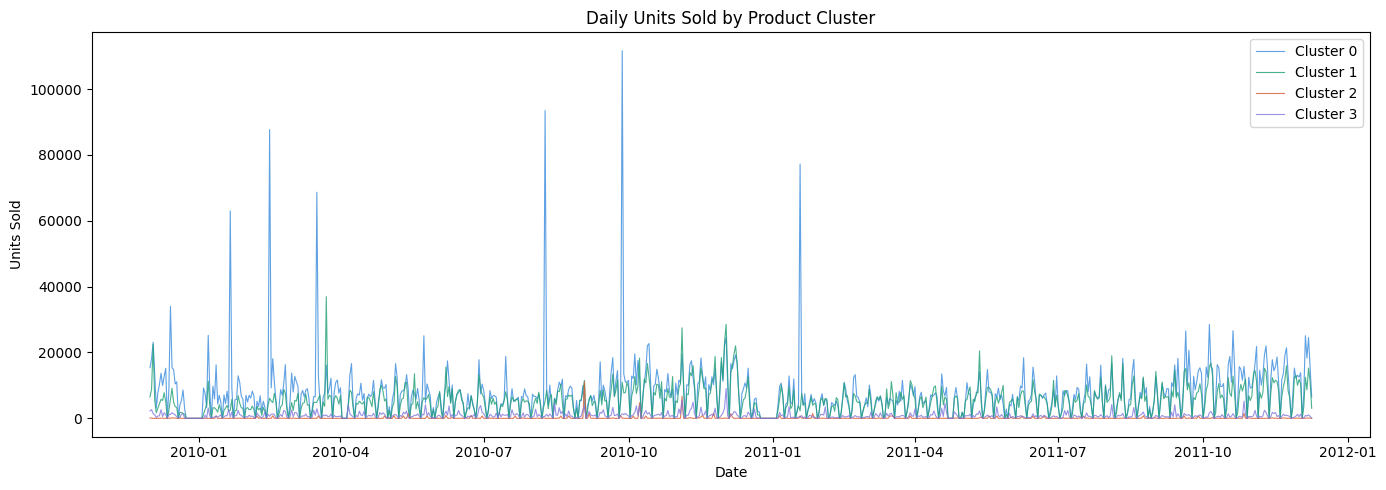

In [103]:
cluster_daily = daily[daily['Cluster'] >= 0].groupby(['Date', 'Cluster'])['units_sold'].sum().reset_index()
colors = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, ax = plt.subplots(figsize=(14, 5))
for cluster_id in sorted(cluster_daily['Cluster'].unique()):
    data = cluster_daily[cluster_daily['Cluster'] == cluster_id]
    ax.plot(data['Date'], data['units_sold'],
            label=f'Cluster {cluster_id}',
            color=colors[cluster_id], alpha=0.8, linewidth=0.8)

ax.set_title('Daily Units Sold by Product Cluster')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Statistical Analysis per Cluster:

**Objective:**
- Understand statistical properties of each cluster before model selection.
- Findings directly inform which models and features are appropriate per cluster.

**Stationarity Testing:**
- ADF (Augmented Dickey-Fuller) test applied — p-value below 0.05 indicates stationarity.
- KPSS test applied — p-value above 0.05 confirms stationarity.
- When ADF and KPSS disagree the series is considered trend-stationary.
- Cluster 0 — ADF stationary, KPSS non-stationary — trend-stationary.
- Cluster 1 — both tests agree stationary.
- Cluster 2 — ADF stationary, KPSS stationary — fully stationary.
- Cluster 3 — ADF stationary, KPSS non-stationary — trend-stationary.

**Seasonal Decomposition:**
- Additive decomposition applied with weekly period of 7 and monthly period of 30.
- Trend, seasonality, and residual components extracted for each cluster.
- All clusters show a strong upward trend peaking mid-2011 followed by a decline.
- Weekly and monthly seasonality patterns are consistent across all clusters.
- Residuals contain large outlier spikes particularly in Clusters 0 and 2.

**ACF and PACF Analysis:**
- ACF and PACF plotted for each cluster up to 60 lags.
- Cluster 0 — weak autocorrelation with small spikes at lag 7.
- Cluster 1 — significant autocorrelation at lags 7, 14, 28, 49 confirming strong weekly memory.
- Cluster 2 — near-zero autocorrelation at all lags — essentially no time series structure.
- Cluster 3 — moderate autocorrelation at lags 7 and 14 similar to Cluster 1 but weaker.

**Cluster Summary:**

| Cluster | Mean | CV% | Kurtosis | Stationarity | Key Pattern |
|---------|------|-----|----------|--------------|-------------|
| 0 | 7903 | 113% | 52.1 | Stationary | Event-driven spikes |
| 1 | 5507 | 83% | 5.1 | Trend-stationary | Weekly cycles |
| 2 | 96 | 306% | 265.5 | Stationary | Sparse intermittent |
| 3 | 835 | 95% | 12.6 | Trend-stationary | Moderate weekly |

In [104]:
from scipy import stats

In [105]:
for cluster_id in sorted(product_clusters['Cluster'].unique()):
    cluster_products = product_clusters[product_clusters['Cluster'] == cluster_id]['Description']
    cluster_data = daily[daily['Description'].isin(cluster_products)]['units_sold']
    print(f"\nCluster {cluster_id} ({len(cluster_products)} products)")
    print(f"  Mean daily units:   {cluster_data.mean():.2f}")
    print(f"  Median daily units: {cluster_data.median():.2f}")
    print(f"  Std dev:            {cluster_data.std():.2f}")
    print(f"  Min:                {cluster_data.min():.2f}")
    print(f"  Max:                {cluster_data.max():.2f}")
    print(f"  Skewness:           {cluster_data.skew():.4f}")
    print(f"  Kurtosis:           {cluster_data.kurtosis():.4f}")
    stat, p = stats.shapiro(cluster_data.sample(min(5000, len(cluster_data)), random_state=42))
    print(f"  Shapiro-Wilk p:     {p:.4f} ({'non-normal' if p < 0.05 else 'normal'})")


Cluster 0 (4484 products)
  Mean daily units:   1.76
  Median daily units: 0.00
  Std dev:            51.10
  Min:                0.00
  Max:                74215.00
  Skewness:           979.3691
  Kurtosis:           1355969.3957
  Shapiro-Wilk p:     0.0000 (non-normal)

Cluster 1 (274 products)
  Mean daily units:   20.10
  Median daily units: 0.00
  Std dev:            86.62
  Min:                0.00
  Max:                11000.00
  Skewness:           46.7623
  Kurtosis:           4510.2056
  Shapiro-Wilk p:     0.0000 (non-normal)

Cluster 2 (1 products)
  Mean daily units:   96.25
  Median daily units: 0.00
  Std dev:            544.07
  Min:                0.00
  Max:                11124.00
  Skewness:           14.8395
  Kurtosis:           265.5436
  Shapiro-Wilk p:     0.0000 (non-normal)

Cluster 3 (10 products)
  Mean daily units:   83.49
  Median daily units: 26.00
  Std dev:            204.28
  Min:                0.00
  Max:                6528.00
  Skewness:       

In [106]:
# Kruskal-Wallis test — do clusters differ significantly in sales?
from scipy.stats import kruskal

groups = []
for cluster_id in sorted(product_clusters['Cluster'].unique()):
    cluster_products = product_clusters[product_clusters['Cluster'] == cluster_id]['Description']
    cluster_data = daily[daily['Description'].isin(cluster_products)]['units_sold'].values
    groups.append(cluster_data)

stat, p = kruskal(*groups)
print(f"\nKruskal-Wallis Test (are cluster sales distributions different?)")
print(f"  H-statistic: {stat:.4f}")
print(f"  p-value:     {p:.6f}")
print(f"  Result:      {'Clusters are significantly different' if p < 0.05 else 'No significant difference'}")


Kruskal-Wallis Test (are cluster sales distributions different?)
  H-statistic: 236860.2956
  p-value:     0.000000
  Result:      Clusters are significantly different


In [107]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

for cluster_id in sorted(cluster_daily['Cluster'].unique()):
    data = cluster_daily[cluster_daily['Cluster'] == cluster_id].set_index('Date')['units_sold']

    print(f"\nCluster {cluster_id}")
    print(f"  Mean:     {data.mean():.2f}")
    print(f"  Std:      {data.std():.2f}")
    print(f"  Skew:     {data.skew():.4f}")
    print(f"  Kurtosis: {data.kurtosis():.4f}")

    # ADF Test — checks stationarity
    adf_stat, adf_p, _, _, _, _ = adfuller(data)
    print(f"  ADF p-value:  {adf_p:.4f} ({'Stationary' if adf_p < 0.05 else 'Non-stationary'})")

    # KPSS Test — confirms stationarity
    kpss_stat, kpss_p, _, _ = kpss(data, regression='c')
    print(f"  KPSS p-value: {kpss_p:.4f} ({'Stationary' if kpss_p > 0.05 else 'Non-stationary'})")


Cluster 0
  Mean:     7903.24
  Std:      8947.19
  Skew:     5.7687
  Kurtosis: 52.1215
  ADF p-value:  0.0000 (Stationary)
  KPSS p-value: 0.1000 (Stationary)

Cluster 1
  Mean:     5506.83
  Std:      4482.42
  Skew:     1.4520
  Kurtosis: 5.1274
  ADF p-value:  0.0261 (Stationary)
  KPSS p-value: 0.0100 (Non-stationary)

Cluster 2
  Mean:     96.25
  Std:      544.07
  Skew:     14.8395
  Kurtosis: 265.5436
  ADF p-value:  0.0000 (Stationary)
  KPSS p-value: 0.1000 (Stationary)

Cluster 3
  Mean:     834.88
  Std:      909.47
  Skew:     2.6555
  Kurtosis: 12.6082
  ADF p-value:  0.0069 (Stationary)
  KPSS p-value: 0.0109 (Non-stationary)


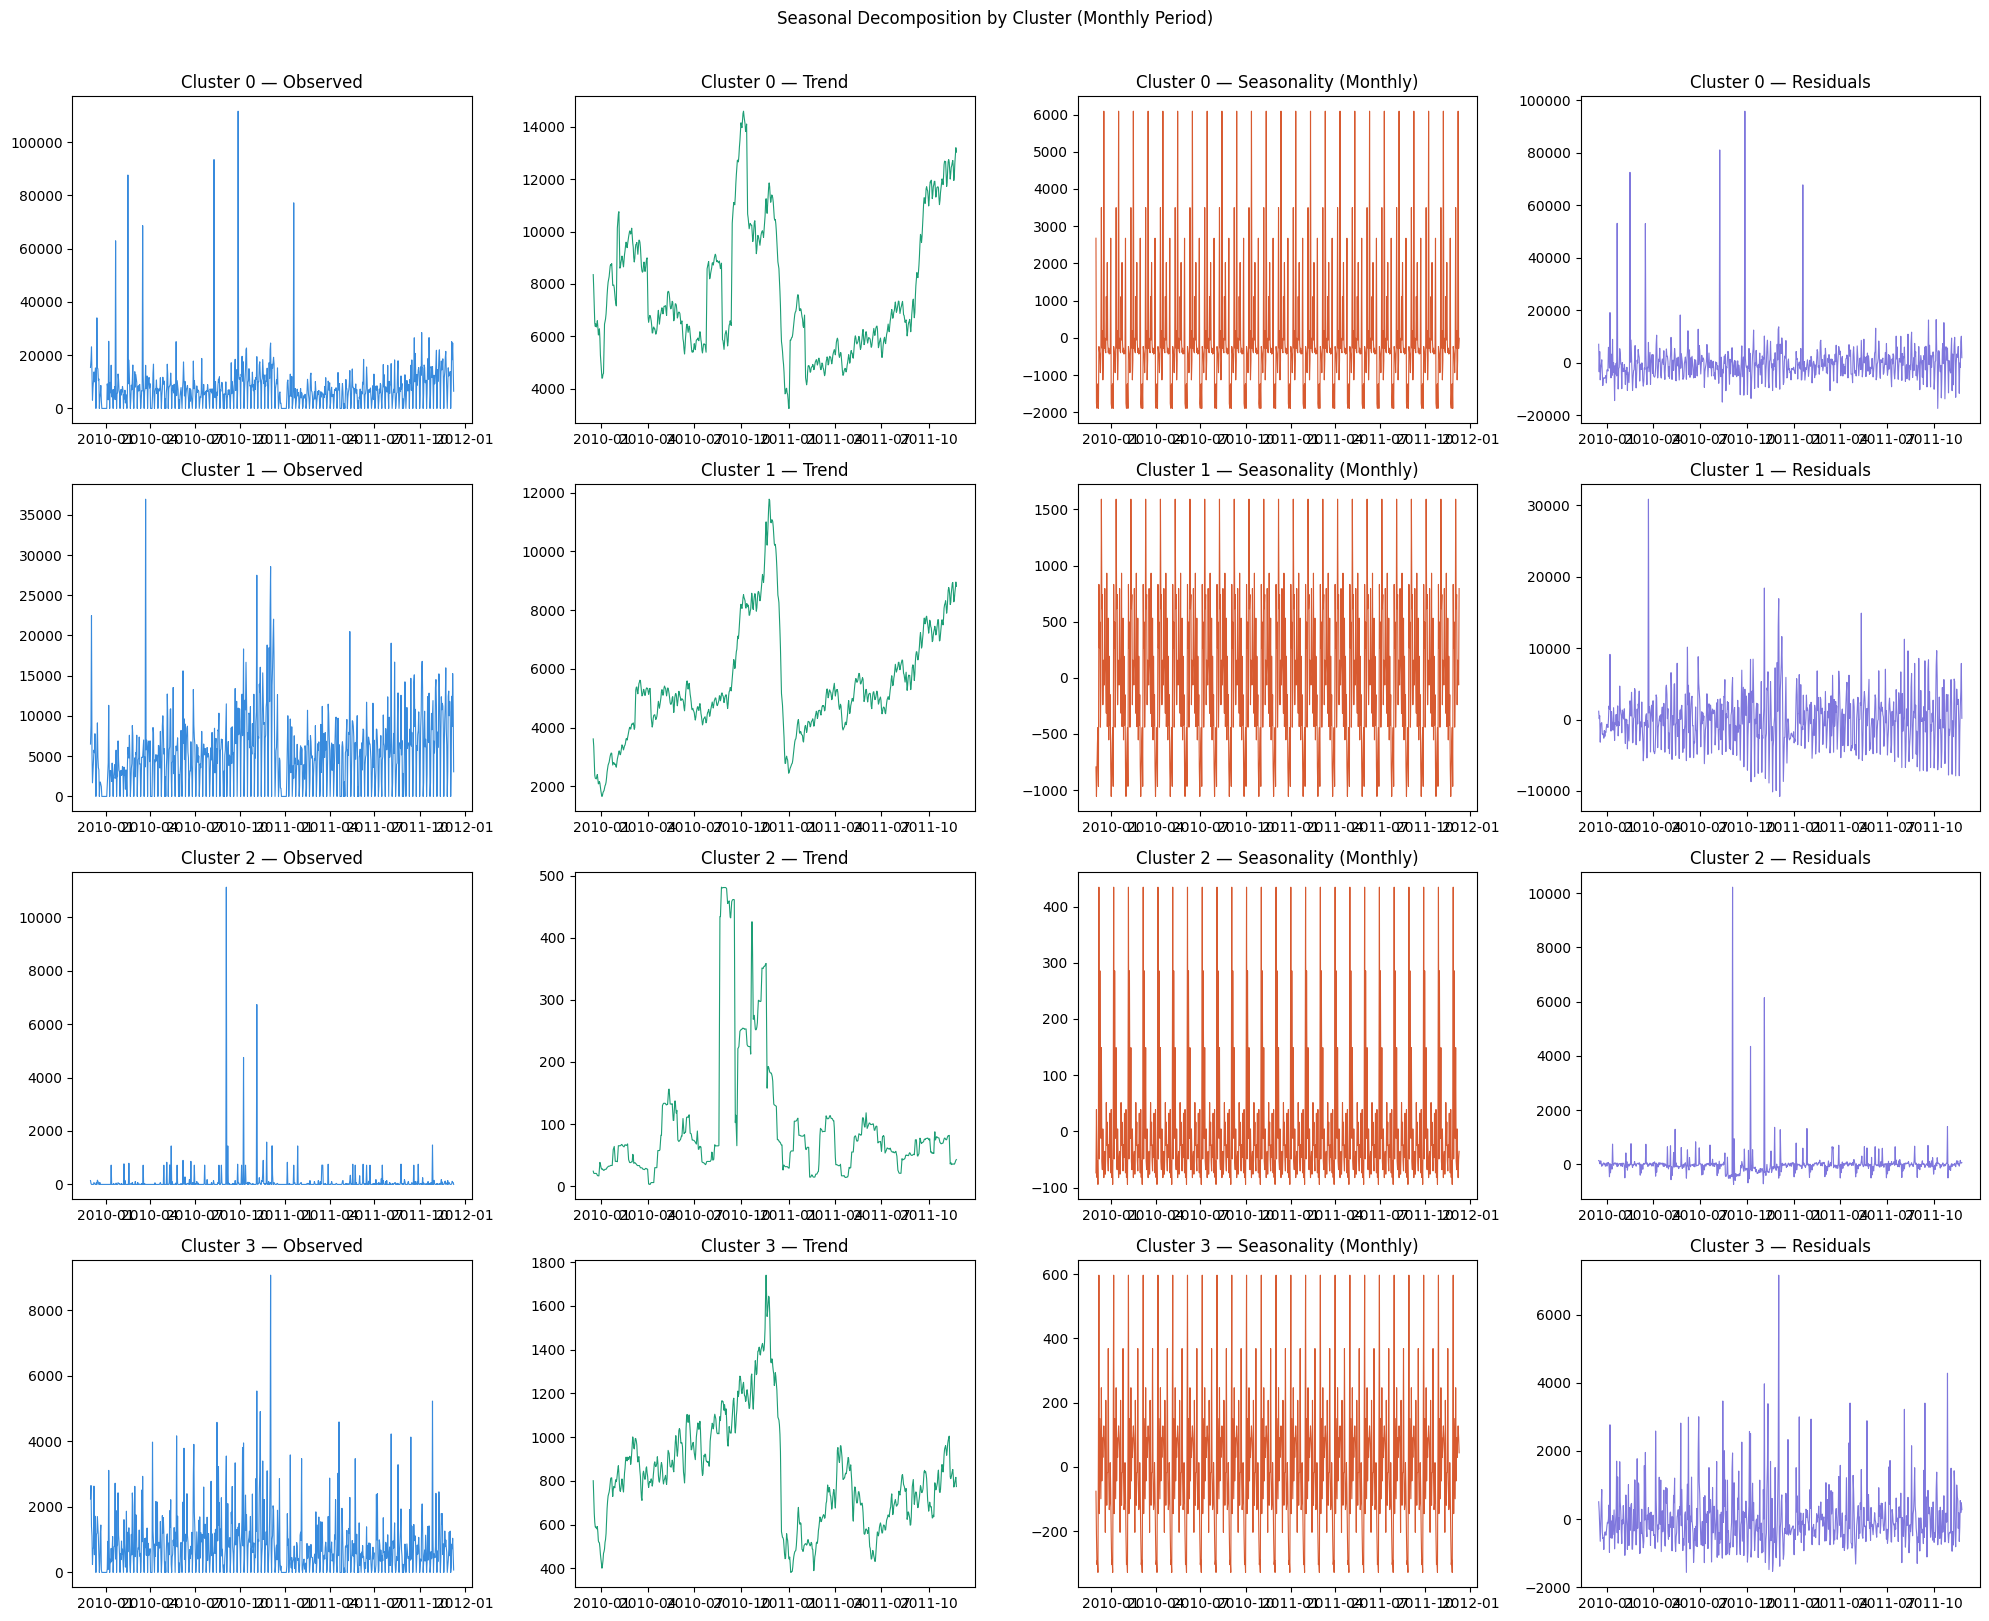

In [109]:
# Monthly seasonality decomposition (period=30)
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for i, cluster_id in enumerate(sorted(cluster_daily['Cluster'].unique())):
    data = cluster_daily[cluster_daily['Cluster'] == cluster_id].set_index('Date')['units_sold']

    decomp = seasonal_decompose(data, model='additive', period=30)

    axes[i][0].plot(decomp.observed,  color='#378ADD', linewidth=0.8)
    axes[i][0].set_title(f'Cluster {cluster_id} — Observed')

    axes[i][1].plot(decomp.trend,     color='#1D9E75', linewidth=0.8)
    axes[i][1].set_title(f'Cluster {cluster_id} — Trend')

    axes[i][2].plot(decomp.seasonal,  color='#D85A30', linewidth=0.8)
    axes[i][2].set_title(f'Cluster {cluster_id} — Seasonality (Monthly)')

    axes[i][3].plot(decomp.resid,     color='#7F77DD', linewidth=0.8)
    axes[i][3].set_title(f'Cluster {cluster_id} — Residuals')

plt.suptitle('Seasonal Decomposition by Cluster (Monthly Period)', y=1.01)
plt.tight_layout()
plt.show()

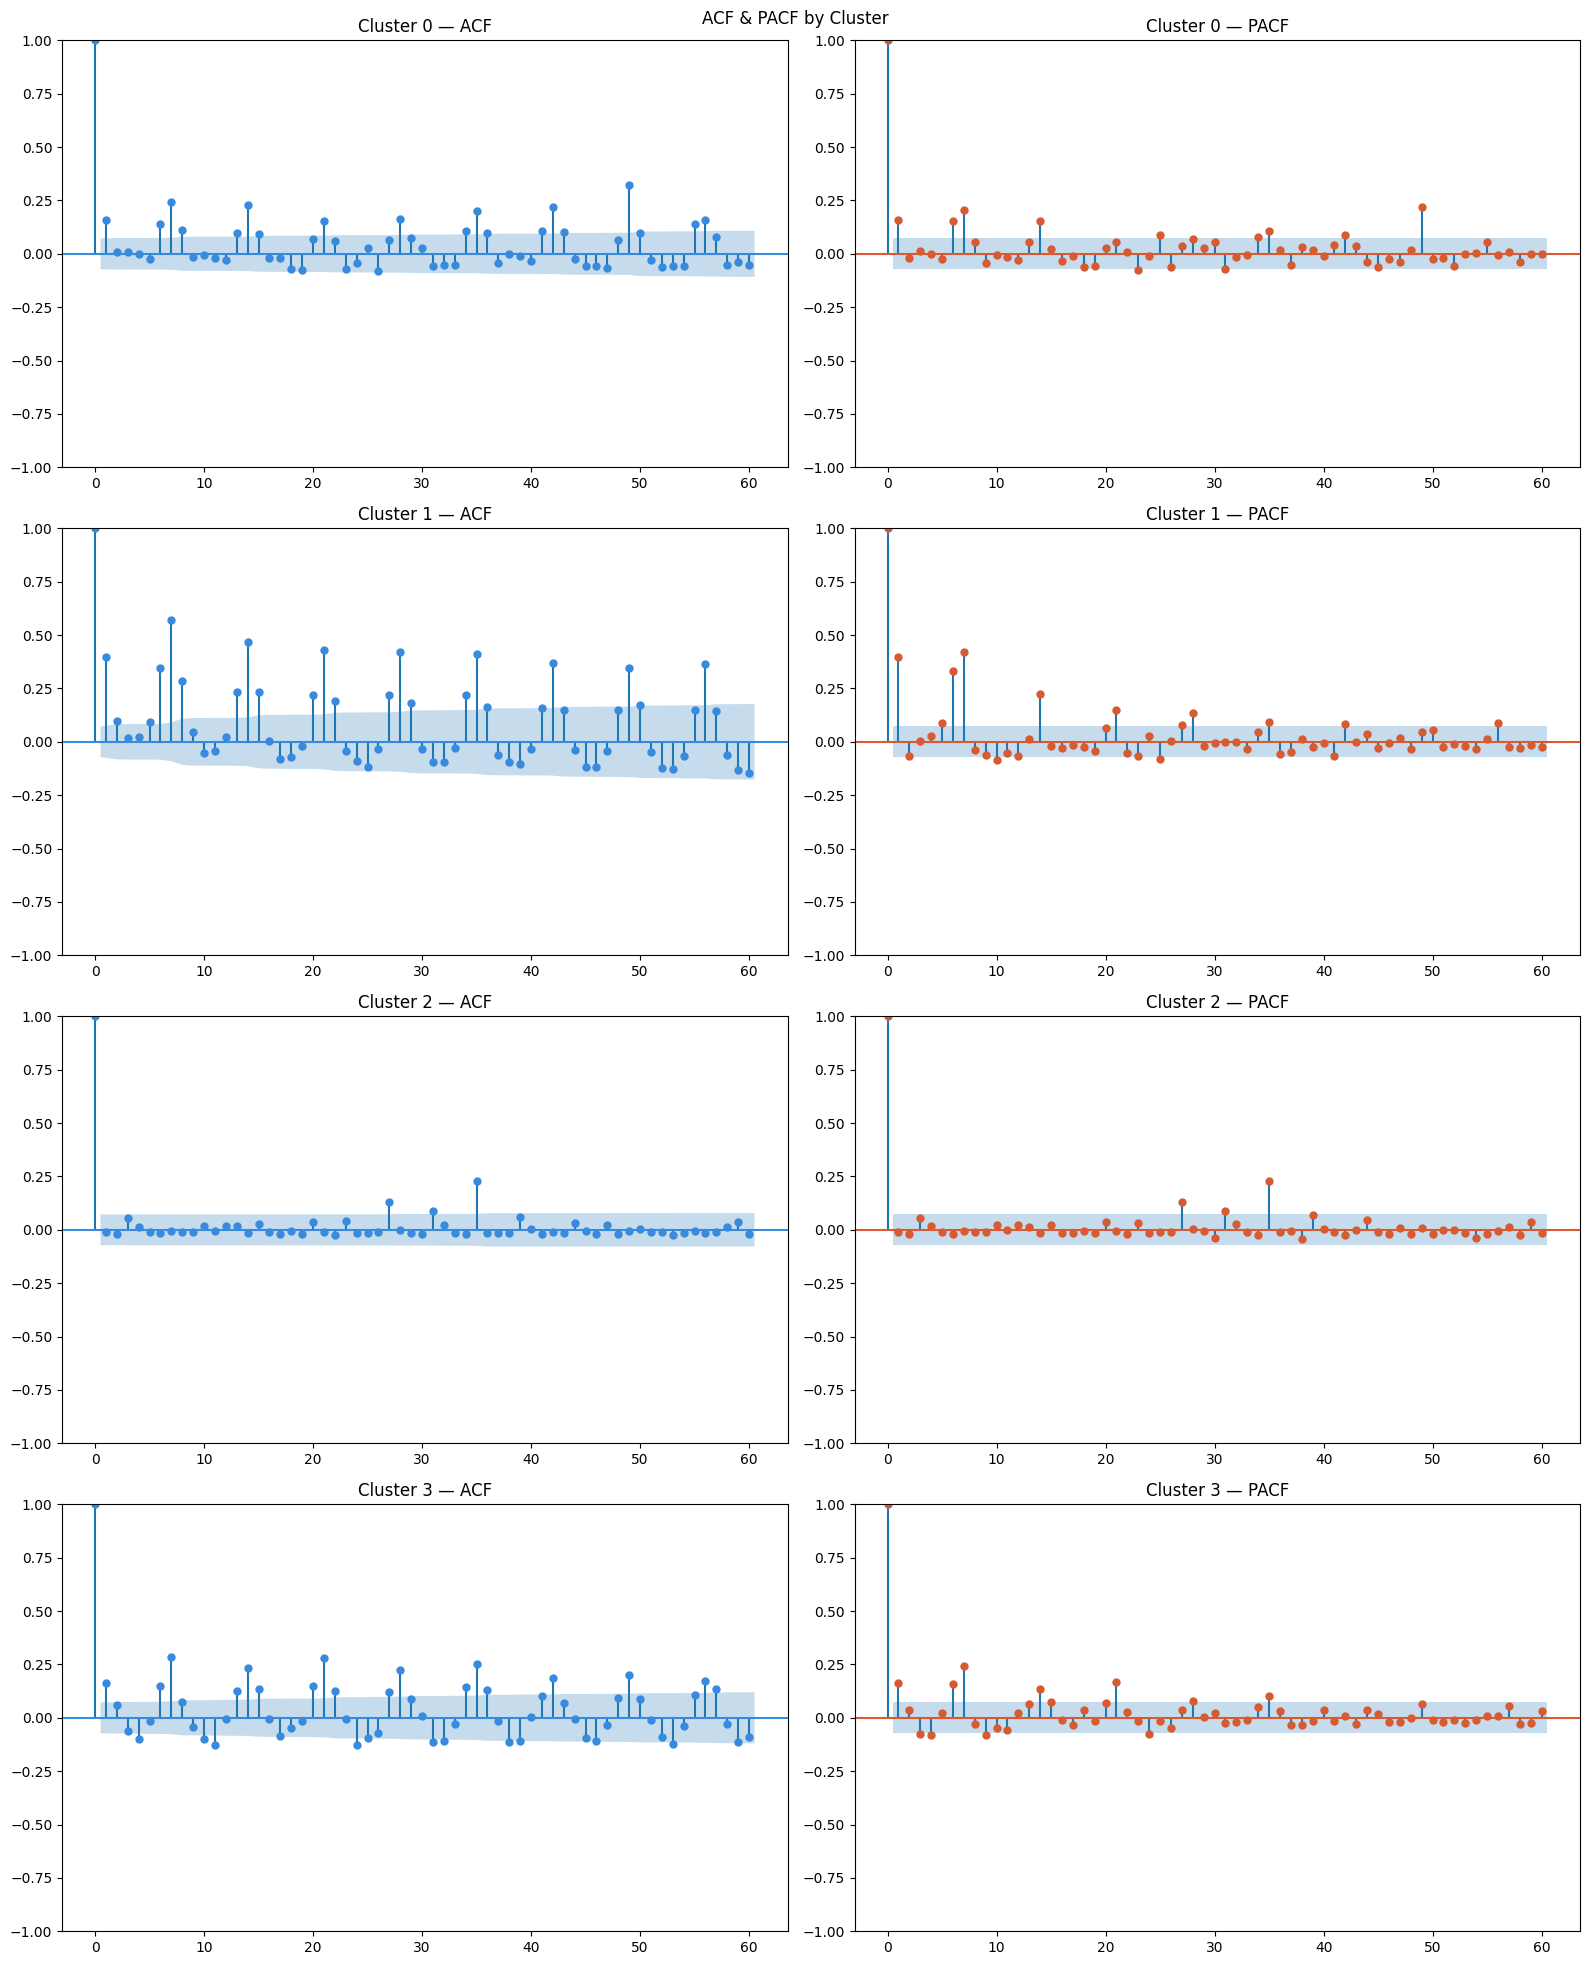

In [110]:
# ACF & PACF — helps determine lag structure
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for i, cluster_id in enumerate(sorted(cluster_daily['Cluster'].unique())):
    data = cluster_daily[cluster_daily['Cluster'] == cluster_id].set_index('Date')['units_sold']

    plot_acf(data,  lags=60, ax=axes[i][0], color='#378ADD')
    axes[i][0].set_title(f'Cluster {cluster_id} — ACF')

    plot_pacf(data, lags=60, ax=axes[i][1], color='#D85A30')
    axes[i][1].set_title(f'Cluster {cluster_id} — PACF')

plt.suptitle('ACF & PACF by Cluster')
plt.tight_layout()
plt.show()

## 5. Feature Engineering:

**Calendar Features:**
- Month (1-12) — captures monthly demand cycles.
- DayOfWeek (0=Monday to 6=Sunday) — captures weekly demand patterns.
- WeekOfYear (1-52) — captures position within the year.
- Quarter (1-4) — captures quarterly seasonality.

**Day Type Flags:**
- is_weekend — 1 if Saturday or Sunday, 0 otherwise.
- is_saturday — 1 if Saturday specifically, important because the data shows near-zero sales on Saturdays.

**UK Public Holidays:**
- Generated using the holidays library for years 2009, 2010, and 2011.
- is_uk_holiday flag covers Christmas Day, Boxing Day, Easter Monday, Bank Holidays and more.
- Captures days when sales patterns deviate significantly from normal.

**Shopping Holidays:**
- is_black_friday — manually defined for November 27 2009, November 26 2010, November 25 2011.
- is_cyber_monday — Monday following Black Friday for each year.
- These events drive significant demand spikes in retail.

**Seasonal Flags:**
- is_christmas_period — 1 for December 20 to December 31.
- is_year_end — 1 for December 26 to December 31.
- is_january — 1 for the entire month of January to capture post-holiday demand drop.

**Lag Features:**
- lag_1 — yesterday's sales, captures daily momentum.
- lag_7 — sales from one week ago, captures weekly cycle memory.
- lag_14 — sales from two weeks ago, captures bi-weekly patterns.
- All lags computed with a one-day shift to prevent data leakage.

**Rolling Statistics:**
- rolling_mean_7 — 7-day rolling average of past sales, captures local trend.
- rolling_std_7 — 7-day rolling standard deviation, captures local volatility.
- Computed with a one-day shift to prevent same-day information leakage.

In [111]:
# Drop existing Cluster column from daily if present
if 'Cluster' in daily.columns:
    daily = daily.drop(columns=['Cluster'])

daily = daily.merge(product_clusters, on='Description', how='left')
daily = daily[daily['Cluster'] >= 0].copy()

# Ensure Date is datetime
daily['Date'] = pd.to_datetime(daily['Date'])

# Time features
daily['Month']       = daily['Date'].dt.month
daily['DayOfWeek']   = daily['Date'].dt.dayofweek
daily['WeekOfYear']  = daily['Date'].dt.isocalendar().week.astype(int)
daily['Quarter']     = daily['Date'].dt.quarter
daily['is_weekend']  = (daily['DayOfWeek'] >= 5).astype(int)

# UK holidays
import holidays
uk_hols           = holidays.UnitedKingdom(years=[2009, 2010, 2011])
uk_holiday_dates  = pd.to_datetime(list(uk_hols.keys()))
daily['is_uk_holiday'] = daily['Date'].isin(uk_holiday_dates).astype(int)

# Shopping holidays
daily['is_black_friday'] = daily['Date'].isin(pd.to_datetime(
    ['2009-11-27', '2010-11-26', '2011-11-25'])).astype(int)
daily['is_cyber_monday'] = daily['Date'].isin(pd.to_datetime(
    ['2009-11-30', '2010-11-29', '2011-11-28'])).astype(int)

# Seasonal flags
daily['is_christmas_period'] = ((daily['Date'].dt.month == 12) & (daily['Date'].dt.day >= 20)).astype(int)
daily['is_year_end']         = ((daily['Date'].dt.month == 12) & (daily['Date'].dt.day >= 26)).astype(int)
daily['is_january']          = (daily['Date'].dt.month == 1).astype(int)

# Aggregate to cluster level
cluster_daily = (
    daily.groupby(['Date', 'Cluster'])
    .agg(
        units_sold          = ('units_sold',          'sum'),
        num_products        = ('Description',         'nunique'),
        Month               = ('Month',               'first'),
        DayOfWeek           = ('DayOfWeek',           'first'),
        WeekOfYear          = ('WeekOfYear',          'first'),
        Quarter             = ('Quarter',             'first'),
        is_weekend          = ('is_weekend',          'first'),
        is_uk_holiday       = ('is_uk_holiday',       'first'),
        is_black_friday     = ('is_black_friday',     'first'),
        is_cyber_monday     = ('is_cyber_monday',     'first'),
        is_christmas_period = ('is_christmas_period', 'first'),
        is_year_end         = ('is_year_end',         'first'),
        is_january          = ('is_january',          'first'),
    )
    .reset_index()
    .sort_values(['Cluster', 'Date'])
)

# Lag & rolling features
for lag in [1, 7, 14]:
    cluster_daily[f'lag_{lag}'] = cluster_daily.groupby('Cluster')['units_sold'].shift(lag)

cluster_daily['rolling_mean_7']  = cluster_daily.groupby('Cluster')['units_sold'].transform(lambda x: x.shift(1).rolling(7).mean())
cluster_daily['rolling_mean_14'] = cluster_daily.groupby('Cluster')['units_sold'].transform(lambda x: x.shift(1).rolling(14).mean())
cluster_daily['rolling_std_7']   = cluster_daily.groupby('Cluster')['units_sold'].transform(lambda x: x.shift(1).rolling(7).std())

cluster_daily = cluster_daily.dropna().reset_index(drop=True)

print(f"Shape: {cluster_daily.shape}")
print(f"Columns: {cluster_daily.columns.tolist()}")
print(cluster_daily.head(3).to_string())

Shape: (2900, 21)
Columns: ['Date', 'Cluster', 'units_sold', 'num_products', 'Month', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'is_weekend', 'is_uk_holiday', 'is_black_friday', 'is_cyber_monday', 'is_christmas_period', 'is_year_end', 'is_january', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']
        Date  Cluster  units_sold  num_products  Month  DayOfWeek  WeekOfYear  Quarter  is_weekend  is_uk_holiday  is_black_friday  is_cyber_monday  is_christmas_period  is_year_end  is_january    lag_1    lag_7   lag_14  rolling_mean_7  rolling_mean_14  rolling_std_7
0 2009-12-15        0       15340          4484     12          1          51        4           0              0                0                0                    0            0           0  34018.0  13701.0  15389.0    13474.142857     13254.428571   10348.364821
1 2009-12-16        0       14809          4484     12          2          51        4           0              0                0     

In [41]:
# Coefficient of Variation & volatility summary
print(f"{'Cluster':<10} {'CV%':>8} {'Trend':>12} {'Weekly Seas':>14} {'Stationarity':>14}")

for cluster_id in sorted(cluster_daily['Cluster'].unique()):
    data  = cluster_daily[cluster_daily['Cluster'] == cluster_id].set_index('Date')['units_sold']
    decomp = seasonal_decompose(data, model='additive', period=7)

    cv          = (data.std() / data.mean()) * 100
    trend_range = decomp.trend.dropna().max() - decomp.trend.dropna().min()
    seas_range  = decomp.seasonal.max() - decomp.seasonal.min()

    adf_stat, adf_p, *_ = adfuller(data)
    stationary = 'Stationary' if adf_p < 0.05 else 'Non-stationary'

    print(f"  {cluster_id:<8} {cv:>8.1f}% {trend_range:>12.1f} {seas_range:>14.1f} {stationary:>14}")

Cluster         CV%        Trend    Weekly Seas   Stationarity
  0            83.2%      16562.9         8333.9     Stationary
  1           117.7%      24005.3        10879.1     Stationary
  2           111.6%       3835.4         1973.5     Stationary


## 6. Cluster Dataframes & Outlier Treatment:

**Separate Dataframes:**
- A separate dataframe created for each cluster containing only its relevant features.
- Prevents irrelevant columns from being passed into models.
- Each dataframe renamed to neuralforecast format — ds for date, y for target, unique_id for cluster identifier.

**Outlier Treatment:**
- Z-score computed for each cluster's daily sales series.
- Values with absolute z-score above 3 replaced with the cluster median.
- Replacement chosen over removal to preserve time series continuity — dropping rows would create gaps.
- Cluster 0 (kurtosis 52.1) — outlier replacement applied.
- Cluster 1 (kurtosis 5.1) — no treatment applied, distribution is near-normal.
- Cluster 2 (kurtosis 265.5) — outlier replacement applied.
- Cluster 3 (kurtosis 12.6) — outlier replacement applied.

**Feature Sets per Cluster:**

| Cluster | Model | Future Exog Features | Historic Exog Features |
|---------|-------|---------------------|----------------------|
| 0 | TiDE | Month, DayOfWeek, WeekOfYear, is_uk_holiday, is_black_friday, is_cyber_monday, is_christmas_period | lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7 |
| 1 | NHITS | Month, DayOfWeek, WeekOfYear, is_uk_holiday, is_christmas_period | lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7 |
| 2 | TimesNet | Month, DayOfWeek, is_uk_holiday, is_black_friday, is_christmas_period | None |
| 3 | NHITS | Month, DayOfWeek, WeekOfYear, is_uk_holiday, is_christmas_period, is_january | lag_1, lag_7, rolling_mean_7, rolling_std_7 |

In [114]:
cluster_features = {
    0: {  # TiDE — strong trend, extreme spikes, event-driven
        'futr': ['Month', 'DayOfWeek', 'WeekOfYear', 'is_uk_holiday',
                 'is_black_friday', 'is_cyber_monday', 'is_christmas_period'],
        'hist': ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
    },
    1: {  # NHITS — strong weekly autocorrelation, trend-stationary
        'futr': ['Month', 'DayOfWeek', 'WeekOfYear', 'is_uk_holiday', 'is_christmas_period'],
        'hist': ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
    },
    2: {  # TimesNet — sparse/intermittent, no autocorrelation
        'futr': ['Month', 'DayOfWeek', 'is_uk_holiday',
                 'is_black_friday', 'is_christmas_period'],
        'hist': []
    },
    3: {  # NHITS — weekly memory, proportionally strong seasonality
        'futr': ['Month', 'DayOfWeek', 'WeekOfYear',
                 'is_uk_holiday', 'is_christmas_period', 'is_january'],
        'hist': ['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
    }
}

cluster_model_name = {0: 'TiDE', 1: 'NHITS', 2: 'TimesNet', 3: 'NHITS'}

print("Cluster feature assignments:")
for c, m in cluster_model_name.items():
    feats = cluster_features[c]['futr'] + cluster_features[c]['hist']
    print(f"  Cluster {c} → {m}  ({len(feats)} features)")

Cluster feature assignments:
  Cluster 0 → TiDE  (12 features)
  Cluster 1 → NHITS  (10 features)
  Cluster 2 → TimesNet  (5 features)
  Cluster 3 → NHITS  (10 features)


In [115]:
from scipy.stats import zscore

cluster_dfs = {}

for cluster_id in [0, 1, 2, 3]:
    futr_cols  = cluster_features[cluster_id]['futr']
    hist_cols  = cluster_features[cluster_id]['hist']
    model_name = cluster_model_name[cluster_id]

    cols = ['Date', 'units_sold'] + futr_cols + hist_cols
    df_c = cluster_daily[cluster_daily['Cluster'] == cluster_id][cols].copy()
    df_c = df_c.rename(columns={'Date': 'ds', 'units_sold': 'y'})
    df_c['unique_id'] = f'Cluster_{cluster_id}'
    df_c = df_c.sort_values('ds').reset_index(drop=True)

    # Remove outliers for high-kurtosis clusters (0, 2, 3)
    # Cluster 1 is most normal (kurtosis 5.1) — keep as is
    if cluster_id in [0, 2, 3]:
        z_scores = np.abs(zscore(df_c['y']))
        n_before = len(df_c)
        df_c.loc[z_scores > 3, 'y'] = df_c['y'].median()  # replace outliers with median
        n_replaced = (z_scores > 3).sum()
        print(f"Cluster {cluster_id} — replaced {n_replaced} outliers out of {n_before} rows")
    else:
        print(f"Cluster {cluster_id} — no outlier removal (kurtosis 5.1, near-normal)")

    cluster_dfs[cluster_id] = df_c

    print(f"  Model:    {model_name}")
    print(f"  Shape:    {df_c.shape}")
    print(f"  Columns:  {df_c.columns.tolist()}")
    print(f"  Date range: {df_c['ds'].min()} to {df_c['ds'].max()}")
    print(f"  y mean:   {df_c['y'].mean():.2f}")
    print(f"  y std:    {df_c['y'].std():.2f}")
    print(f"  y max:    {df_c['y'].max():.2f}")
    print()

Cluster 0 — replaced 6 outliers out of 725 rows
  Model:    TiDE
  Shape:    (725, 15)
  Columns:  ['ds', 'y', 'Month', 'DayOfWeek', 'WeekOfYear', 'is_uk_holiday', 'is_black_friday', 'is_cyber_monday', 'is_christmas_period', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'unique_id']
  Date range: 2009-12-15 00:00:00 to 2011-12-09 00:00:00
  y mean:   7163.61
  y std:    5436.27
  y max:    28505.00

Cluster 1 — no outlier removal (kurtosis 5.1, near-normal)
  Model:    NHITS
  Shape:    (725, 13)
  Columns:  ['ds', 'y', 'Month', 'DayOfWeek', 'WeekOfYear', 'is_uk_holiday', 'is_christmas_period', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'unique_id']
  Date range: 2009-12-15 00:00:00 to 2011-12-09 00:00:00
  y mean:   5496.58
  y std:    4469.19
  y max:    36937.00

Cluster 2 — replaced 3 outliers out of 725 rows
  Model:    TimesNet
  Shape:    (725, 8)
  Columns:  ['ds', 'y', 'Month', 'DayOfWeek', 'is_uk_holiday', 'is_black_friday', 'is_christmas_

In [116]:
# Verify all 4 dataframes
for cluster_id in [0, 1, 2, 3]:
    print(f"cluster_dfs[{cluster_id}] — {cluster_model_name[cluster_id]}")
    print(cluster_dfs[cluster_id].head(3).to_string())
    print()

cluster_dfs[0] — TiDE
          ds      y  Month  DayOfWeek  WeekOfYear  is_uk_holiday  is_black_friday  is_cyber_monday  is_christmas_period    lag_1    lag_7   lag_14  rolling_mean_7  rolling_std_7  unique_id
0 2009-12-15  15340     12          1          51              0                0                0                    0  34018.0  13701.0  15389.0    13474.142857   10348.364821  Cluster_0
1 2009-12-16  14809     12          2          51              0                0                0                    0  15340.0   9966.0  18119.0    13708.285714   10372.866250  Cluster_0
2 2009-12-17  10457     12          3          51              0                0                0                    0  14809.0  12749.0  23117.0    14400.142857   10242.349428  Cluster_0

cluster_dfs[1] — NHITS
          ds     y  Month  DayOfWeek  WeekOfYear  is_uk_holiday  is_christmas_period   lag_1   lag_7   lag_14  rolling_mean_7  rolling_std_7  unique_id
0 2009-12-15  9137     12          1          

In [43]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.7 MB/s eta 0:00:00
  Attempting uninstall: tornado
    Found existing installation: tornado 6.5.1
    Uninstalling tornado-6.5.1:
      Successfully uninstalled tornado-6.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour i

## 7. Model Definitions:

**General Settings:**
- Forecast horizon set to 60 days for all models.
- Loss function — Mean Absolute Error (MAE) for all models.
- Learning rate — 1e-4 for all models.
- Maximum training steps — 1000 for all models.
- Batch size — 32 for all models.
- Early stopping disabled to allow full training.

**PatchTST:**
- Transformer-based model that divides the input series into patches and applies self-attention across patches.
- Captures long-range dependencies efficiently without attending to every individual time step.
- Input size of 180 days, patch length 16, stride 8, 4 attention heads, hidden size 128, 3 encoder layers.
- Does not support exogenous variables — relies purely on historical target values.

**TiDE (Time-series Dense Encoder):**
- Dense encoder-decoder architecture designed for long-horizon forecasting.
- Supports both future and historical exogenous inputs.
- Suitable for clusters where calendar features and lag features are both informative.
- Hidden size 512, 2 encoder layers, 2 decoder layers.

**NHITS (Neural Hierarchical Interpolation for Time Series):**
- Uses hierarchical interpolation across multiple temporal scales.
- Decomposes forecast into components capturing different frequencies simultaneously.
- Supports both future and historical exogenous inputs.
- 3 stacks with pool kernel sizes 2, 2, 1 and frequency downsampling 4, 2, 1, MLP units 512.

**NBEATS (Neural Basis Expansion Analysis):**
- Uses basis expansion with interpretable trend and seasonality blocks.
- Does not support exogenous variables — relies entirely on historical target series.
- 2 harmonics, 2 polynomials, MLP units 512 per layer, 3 stacks.

**TimesNet:**
- Transforms the 1D time series into 2D representations to capture temporal variations.
- Supports future exogenous inputs only — no historical exogenous support.
- Hidden size 64, convolutional hidden size 64, top-k frequency components 5.

In [119]:
from neuralforecast import NeuralForecast
from neuralforecast.models import TiDE, NHITS, TimesNet, NBEATS, PatchTST
from neuralforecast.losses.pytorch import MAE

horizon = 60

# PatchTST — no exog support, pure time series
def get_patchtst():
    return PatchTST(
        h                         = horizon,
        input_size                = 180,
        patch_len                 = 16,
        stride                    = 8,
        n_heads                   = 4,
        hidden_size               = 128,
        linear_hidden_size        = 256,
        encoder_layers            = 3,
        dropout                   = 0.1,
        fc_dropout                = 0.1,
        max_steps                 = 1000,
        learning_rate             = 1e-4,
        loss                      = MAE(),
        batch_size                = 32,
        early_stop_patience_steps = -1,
        random_seed               = 42
    )

# TiDE — FUTR + HIST exog
def get_tide(futr_cols, hist_cols):
    return TiDE(
        h                         = horizon,
        input_size                = 180,
        futr_exog_list            = futr_cols,
        hist_exog_list            = hist_cols,
        hidden_size               = 512,
        decoder_output_dim        = 32,
        temporal_width_past       = 4,
        temporal_width_future     = 4,
        temporal_decoder_hidden   = 128,
        num_encoder_layers        = 2,
        num_decoder_layers        = 2,
        dropout                   = 0.1,
        max_steps                 = 1000,
        learning_rate             = 1e-4,
        loss                      = MAE(),
        batch_size                = 32,
        early_stop_patience_steps = -1,
        random_seed               = 42
    )

# NHITS — FUTR + HIST exog
def get_nhits(futr_cols, hist_cols):
    return NHITS(
        h                         = horizon,
        input_size                = 180,
        futr_exog_list            = futr_cols,
        hist_exog_list            = hist_cols,
        n_pool_kernel_size        = [2, 2, 1],
        n_freq_downsample         = [4, 2, 1],
        mlp_units                 = [[512, 512], [512, 512], [512, 512]],
        n_blocks                  = [1, 1, 1],
        dropout_prob_theta        = 0.1,
        max_steps                 = 1000,
        learning_rate             = 1e-4,
        loss                      = MAE(),
        batch_size                = 32,
        early_stop_patience_steps = -1,
        random_seed               = 42
    )

# NBEATS — no exog support
def get_nbeats():
    return NBEATS(
        h                         = horizon,
        input_size                = 180,
        n_harmonics               = 2,
        n_polynomials             = 2,
        mlp_units                 = [[512, 512], [512, 512], [512, 512]],
        n_blocks                  = [1, 1, 1],
        max_steps                 = 1000,
        learning_rate             = 1e-4,
        loss                      = MAE(),
        batch_size                = 32,
        early_stop_patience_steps = -1,
        random_seed               = 42
    )

# TimesNet — FUTR only
def get_timesnet(futr_cols):
    return TimesNet(
        h                         = horizon,
        input_size                = 180,
        futr_exog_list            = futr_cols,
        hidden_size               = 64,
        conv_hidden_size          = 64,
        n_layers                  = 2,
        top_k                     = 5,
        dropout                   = 0.1,
        max_steps                 = 1000,
        learning_rate             = 1e-4,
        loss                      = MAE(),
        batch_size                = 32,
        early_stop_patience_steps = -1,
        random_seed               = 42
    )

print("Model factory functions defined:")
print("  get_patchtst()              — no exog")
print("  get_tide(futr, hist)        — FUTR + HIST")
print("  get_nhits(futr, hist)       — FUTR + HIST")
print("  get_nbeats()                — no exog")
print("  get_timesnet(futr)          — FUTR only")

Model factory functions defined:
  get_patchtst()              — no exog
  get_tide(futr, hist)        — FUTR + HIST
  get_nhits(futr, hist)       — FUTR + HIST
  get_nbeats()                — no exog
  get_timesnet(futr)          — FUTR only


In [120]:
# Models assigned per cluster
cluster_model_configs = {
    0: [  # TiDE, NHITS, PatchTST — high volume, event-driven
        ('TiDE',     get_tide(cluster_features[0]['futr'], cluster_features[0]['hist'])),
        ('NHITS',    get_nhits(cluster_features[0]['futr'], cluster_features[0]['hist'])),
        ('PatchTST', get_patchtst()),
        ('NBEATS',   get_nbeats()),
    ],
    1: [  # NHITS, TiDE, PatchTST — weekly autocorrelation, trend-stationary
        ('NHITS',    get_nhits(cluster_features[1]['futr'], cluster_features[1]['hist'])),
        ('TiDE',     get_tide(cluster_features[1]['futr'], cluster_features[1]['hist'])),
        ('PatchTST', get_patchtst()),
        ('NBEATS',   get_nbeats()),
    ],
    2: [  # TimesNet, NHITS — sparse, no autocorrelation
        ('TimesNet', get_timesnet(cluster_features[2]['futr'])),
        ('NBEATS',   get_nbeats()),
        ('PatchTST', get_patchtst()),
    ],
    3: [  # NHITS, TiDE, PatchTST — weekly memory, seasonal
        ('NHITS',    get_nhits(cluster_features[3]['futr'], cluster_features[3]['hist'])),
        ('TiDE',     get_tide(cluster_features[3]['futr'], cluster_features[3]['hist'])),
        ('PatchTST', get_patchtst()),
        ('NBEATS',   get_nbeats()),
    ]
}

print("Models per cluster:")
for c, configs in cluster_model_configs.items():
    print(f"  Cluster {c}: {[m for m, _ in configs]}")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


Models per cluster:
  Cluster 0: ['TiDE', 'NHITS', 'PatchTST', 'NBEATS']
  Cluster 1: ['NHITS', 'TiDE', 'PatchTST', 'NBEATS']
  Cluster 2: ['TimesNet', 'NBEATS', 'PatchTST']
  Cluster 3: ['NHITS', 'TiDE', 'PatchTST', 'NBEATS']


## 8. Model Training & Evaluation:

**Train-Test Split:**
- Last 60 days of each cluster's series held out as the test set.
- All data prior to the cutoff used for training.
- Validation size set to 60 days within the training loop for convergence monitoring.

**Models Tested per Cluster:**
- Cluster 0 — TiDE, NHITS, PatchTST, NBEATS.
- Cluster 1 — NHITS, TiDE, PatchTST, NBEATS.
- Cluster 2 — TimesNet, NBEATS, PatchTST.
- Cluster 3 — NHITS, TiDE, PatchTST, NBEATS.

**Evaluation Metric — SMAPE:**
- Symmetric Mean Absolute Percentage Error used as the primary metric.
- Formula — 2 × |actual - predicted| / (|actual| + |predicted|) × 100.
- Chosen over MAPE because it handles zero actual values without producing infinite errors.
- Bounded between 0% and 200% — lower is better.

**Results:**

| Cluster | Model | SMAPE | MAE | RMSE |
|---------|-------|-------|-----|------|
| Cluster_0 | NHITS | 59.55% | 6229.37 | 7238.33 |
| Cluster_0 | NBEATS | 59.68% | 4489.54 | 5714.75 |
| Cluster_0 | PatchTST | 82.31% | 6047.33 | 7515.78 |
| Cluster_1 | NHITS | 56.51% | 2641.76 | 3285.40 |
| Cluster_1 | PatchTST | 58.10% | 2622.12 | 3320.02 |
| Cluster_1 | NBEATS | 59.19% | 2783.15 | 3532.29 |
| Cluster_2 | NBEATS | 141.53% | 87.15 | 204.74 |
| Cluster_2 | PatchTST | 147.73% | 56.79 | 194.66 |
| Cluster_3 | NHITS | 68.73% | 355.10 | 508.06 |
| Cluster_3 | NBEATS | 76.73% | 413.98 | 538.44 |
| Cluster_3 | PatchTST | 80.13% | 355.45 | 456.37 |

**Best Model per Cluster:**
- Cluster 0 — NHITS with SMAPE 59.55%.
- Cluster 1 — NHITS with SMAPE 56.51%.
- Cluster 2 — NBEATS with SMAPE 141.53%.
- Cluster 3 — NHITS with SMAPE 68.73%.

In [121]:
all_results = []

for cluster_id in [0, 1, 2, 3]:
    futr_cols = cluster_features[cluster_id]['futr']
    hist_cols = cluster_features[cluster_id]['hist']
    df_c      = cluster_dfs[cluster_id].copy()

    cutoff = df_c['ds'].max() - pd.Timedelta(days=horizon)
    train  = df_c[df_c['ds'] <= cutoff]
    test   = df_c[df_c['ds'] >  cutoff]

    print(f"\nCluster {cluster_id} — Train: {len(train)}  Test: {len(test)}")

    for model_name, model in cluster_model_configs[cluster_id]:
        print(f"  Training {model_name}...")
        try:
            nf = NeuralForecast(models=[model], freq='D')
            nf.fit(df=train, val_size=horizon)

            # PatchTST and NBEATS need no futr_df
            if model_name in ['PatchTST', 'NBEATS']:
                preds = nf.predict().reset_index()
            else:
                preds = nf.predict(futr_df=test).reset_index()

            actual = test.sort_values('ds')['y'].values
            pred   = preds.sort_values('ds')[model_name].values
            n      = min(len(actual), len(pred))
            smape  = np.mean(2 * np.abs(pred[:n] - actual[:n]) / (np.abs(actual[:n]) + np.abs(pred[:n]) + 1e-8)) * 100
            mae    = np.mean(np.abs(actual[:n] - pred[:n]))
            rmse   = np.sqrt(np.mean((actual[:n] - pred[:n]) ** 2))

            print(f"    SMAPE={smape:.2f}%  MAE={mae:.2f}  RMSE={rmse:.2f}")
            all_results.append({'Cluster': f'Cluster_{cluster_id}', 'Model': model_name,
                                'SMAPE': round(smape,2), 'MAE': round(mae,2), 'RMSE': round(rmse,2)})
        except Exception as e:
            print(f"    Failed: {e}")

print("\nAll Results:")
results_df = pd.DataFrame(all_results)
print(results_df.sort_values(['Cluster','SMAPE']).to_string(index=False))

print("\nBest model per cluster:")
best = results_df.loc[results_df.groupby('Cluster')['SMAPE'].idxmin()]
print(best.to_string(index=False))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Cluster 0 — Train: 665  Test: 60
  Training TiDE...
    Failed: Trainer.__init__() got an unexpected keyword argument 'temporal_width_past'
  Training NHITS...


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  5.5 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 5.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.5 M                                                                                                
Total estimated model params size (MB): 22                                                                         
Modules in train mode: 43                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

    SMAPE=76.73%  MAE=413.98  RMSE=538.44

All Results:
  Cluster    Model  SMAPE     MAE    RMSE
Cluster_0    NHITS  59.55 6229.37 7238.33
Cluster_0   NBEATS  59.68 4489.54 5714.75
Cluster_0 PatchTST  82.31 6047.33 7515.78
Cluster_1    NHITS  56.51 2641.76 3285.40
Cluster_1 PatchTST  58.10 2622.12 3320.02
Cluster_1   NBEATS  59.19 2783.15 3532.29
Cluster_2   NBEATS 141.53   87.15  204.74
Cluster_2 PatchTST 147.73   56.79  194.66
Cluster_3    NHITS  68.73  355.10  508.06
Cluster_3   NBEATS  76.73  413.98  538.44
Cluster_3 PatchTST  80.13  355.45  456.37

Best model per cluster:
  Cluster  Model  SMAPE     MAE    RMSE
Cluster_0  NHITS  59.55 6229.37 7238.33
Cluster_1  NHITS  56.51 2641.76 3285.40
Cluster_2 NBEATS 141.53   87.15  204.74
Cluster_3  NHITS  68.73  355.10  508.06


In [123]:
import inspect
from neuralforecast.models import TiDE, TimesNet
print("TiDE params:")
print(inspect.signature(TiDE.__init__))
print("\nTimesNet params:")
print(inspect.signature(TimesNet.__init__))

TiDE params:
(self, h, input_size, hidden_size=512, decoder_output_dim=32, temporal_decoder_dim=128, dropout=0.3, layernorm=True, num_encoder_layers=1, num_decoder_layers=1, temporal_width=4, futr_exog_list=None, hist_exog_list=None, stat_exog_list=None, exclude_insample_y=False, loss=MAE(), valid_loss=None, max_steps: int = 1000, learning_rate: float = 0.001, num_lr_decays: int = -1, early_stop_patience_steps: int = -1, val_monitor: str = 'ptl/val_loss', val_check_steps: int = 100, batch_size: int = 32, valid_batch_size: Optional[int] = None, windows_batch_size=1024, inference_windows_batch_size=1024, start_padding_enabled=False, training_data_availability_threshold=0.0, step_size: int = 1, scaler_type: str = 'identity', random_seed: int = 1, drop_last_loader: bool = False, alias: Optional[str] = None, optimizer=None, optimizer_kwargs=None, lr_scheduler=None, lr_scheduler_kwargs=None, dataloader_kwargs=None, **trainer_kwargs)

TimesNet params:
(self, h: int, input_size: int, stat_exog

## 9. Hyperparameter Tuning:

**Objective:**
- Improve SMAPE of the best performing model per cluster by tuning key hyperparameters.
- Three hyperparameters varied — input_size (lookback window), max_steps (training duration), learning_rate.

**Models Tuned:**
- Cluster 0 — NHITS.
- Cluster 1 — NHITS.
- Cluster 2 — NBEATS.
- Cluster 3 — NHITS.

**Configurations Tested:**
- input_size 120 with learning_rate 1e-3 and 2000 steps — tests shorter lookback with faster learning.
- input_size 180 with learning_rate 5e-4 and 2000 steps — tests moderate learning rate with more steps.
- input_size 360 with learning_rate 1e-4 and 2000 steps — tests longer lookback window.
- input_size 180 with learning_rate 1e-4 and 3000 steps — tests more training time at original settings.

**Rationale for Hyperparameters:**
- input_size controls how far back the model looks — longer lookback captures more seasonal cycles but risks overfitting.
- learning_rate controls step size during gradient descent — higher values converge faster but may overshoot.
- max_steps controls total training duration — more steps allow better convergence but increase risk of overfitting.

In [122]:
# Hyperparameter tuning for best model per cluster
# Best so far: Cluster 0 NHITS, Cluster 1 NHITS, Cluster 2 NBEATS, Cluster 3 NHITS

tuning_results = []

# Tuning configs to try
nhits_configs = [
    {'input_size': 120, 'max_steps': 2000, 'learning_rate': 1e-3, 'label': 'lr=1e-3,steps=2000,in=120'},
    {'input_size': 180, 'max_steps': 2000, 'learning_rate': 5e-4, 'label': 'lr=5e-4,steps=2000,in=180'},
    {'input_size': 360, 'max_steps': 2000, 'learning_rate': 1e-4, 'label': 'lr=1e-4,steps=2000,in=360'},
    {'input_size': 180, 'max_steps': 3000, 'learning_rate': 1e-4, 'label': 'lr=1e-4,steps=3000,in=180'},
]

nbeats_configs = [
    {'input_size': 120, 'max_steps': 2000, 'learning_rate': 1e-3, 'label': 'lr=1e-3,steps=2000,in=120'},
    {'input_size': 180, 'max_steps': 2000, 'learning_rate': 5e-4, 'label': 'lr=5e-4,steps=2000,in=180'},
    {'input_size': 360, 'max_steps': 2000, 'learning_rate': 1e-4, 'label': 'lr=1e-4,steps=2000,in=360'},
    {'input_size': 180, 'max_steps': 3000, 'learning_rate': 1e-4, 'label': 'lr=1e-4,steps=3000,in=180'},
]

best_per_cluster = {
    0: ('NHITS', nhits_configs,  cluster_features[0]['futr'], cluster_features[0]['hist']),
    1: ('NHITS', nhits_configs,  cluster_features[1]['futr'], cluster_features[1]['hist']),
    2: ('NBEATS', nbeats_configs, [], []),
    3: ('NHITS', nhits_configs,  cluster_features[3]['futr'], cluster_features[3]['hist']),
}

for cluster_id, (model_name, configs, futr_cols, hist_cols) in best_per_cluster.items():
    df_c   = cluster_dfs[cluster_id].copy()
    cutoff = df_c['ds'].max() - pd.Timedelta(days=horizon)
    train  = df_c[df_c['ds'] <= cutoff]
    test   = df_c[df_c['ds'] >  cutoff]

    print(f"\nTuning {model_name} on Cluster {cluster_id}...")

    for cfg in configs:
        label = cfg['label']
        try:
            if model_name == 'NHITS':
                model = NHITS(
                    h                         = horizon,
                    input_size                = cfg['input_size'],
                    futr_exog_list            = futr_cols,
                    hist_exog_list            = hist_cols,
                    n_pool_kernel_size        = [2, 2, 1],
                    n_freq_downsample         = [4, 2, 1],
                    mlp_units                 = [[512, 512], [512, 512], [512, 512]],
                    n_blocks                  = [1, 1, 1],
                    max_steps                 = cfg['max_steps'],
                    learning_rate             = cfg['learning_rate'],
                    loss                      = MAE(),
                    batch_size                = 32,
                    early_stop_patience_steps = -1,
                    random_seed               = 42
                )
            else:
                model = NBEATS(
                    h                         = horizon,
                    input_size                = cfg['input_size'],
                    n_harmonics               = 2,
                    n_polynomials             = 2,
                    mlp_units                 = [[512, 512], [512, 512], [512, 512]],
                    n_blocks                  = [1, 1, 1],
                    max_steps                 = cfg['max_steps'],
                    learning_rate             = cfg['learning_rate'],
                    loss                      = MAE(),
                    batch_size                = 32,
                    early_stop_patience_steps = -1,
                    random_seed               = 42
                )

            nf = NeuralForecast(models=[model], freq='D')
            nf.fit(df=train, val_size=horizon)

            if futr_cols:
                preds = nf.predict(futr_df=test).reset_index()
            else:
                preds = nf.predict().reset_index()

            actual = test.sort_values('ds')['y'].values
            pred   = preds.sort_values('ds')[model_name].values
            n      = min(len(actual), len(pred))
            smape  = np.mean(2 * np.abs(pred[:n] - actual[:n]) / (np.abs(actual[:n]) + np.abs(pred[:n]) + 1e-8)) * 100
            mae    = np.mean(np.abs(actual[:n] - pred[:n]))
            rmse   = np.sqrt(np.mean((actual[:n] - pred[:n]) ** 2))

            print(f"  {label}  SMAPE={smape:.2f}%  MAE={mae:.2f}  RMSE={rmse:.2f}")
            tuning_results.append({'Cluster': f'Cluster_{cluster_id}', 'Model': model_name,
                                   'Config': label, 'SMAPE': round(smape,2),
                                   'MAE': round(mae,2), 'RMSE': round(rmse,2)})
        except Exception as e:
            print(f"  {label} Failed: {e}")

tuning_df = pd.DataFrame(tuning_results)
print("\nTuning Results:")
print(tuning_df.sort_values(['Cluster','SMAPE']).to_string(index=False))

print("\nBest config per cluster:")
best_tuned = tuning_df.loc[tuning_df.groupby('Cluster')['SMAPE'].idxmin()]
print(best_tuned.to_string(index=False))

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Tuning NHITS on Cluster 0...


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  4.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 4.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.6 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=3000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

  lr=1e-4,steps=3000,in=180  SMAPE=72.62%  MAE=375.32  RMSE=533.95

Tuning Results:
  Cluster  Model                    Config  SMAPE     MAE    RMSE
Cluster_0  NHITS lr=1e-4,steps=2000,in=360  55.45 5791.61 6960.08
Cluster_0  NHITS lr=5e-4,steps=2000,in=180  58.42 5790.17 6901.37
Cluster_0  NHITS lr=1e-4,steps=3000,in=180  59.91 6351.34 7384.61
Cluster_0  NHITS lr=1e-3,steps=2000,in=120  60.73 6362.50 8021.91
Cluster_1  NHITS lr=1e-4,steps=2000,in=360  52.84 2900.40 3339.26
Cluster_1  NHITS lr=1e-3,steps=2000,in=120  59.25 2970.07 3603.74
Cluster_1  NHITS lr=1e-4,steps=3000,in=180  59.66 2994.61 3748.40
Cluster_1  NHITS lr=5e-4,steps=2000,in=180  61.89 3195.23 4028.75
Cluster_2 NBEATS lr=1e-4,steps=3000,in=180 148.96  116.88  229.40
Cluster_2 NBEATS lr=5e-4,steps=2000,in=180 150.27   96.52  214.18
Cluster_2 NBEATS lr=1e-4,steps=2000,in=360 152.05  110.42  208.63
Cluster_2 NBEATS lr=1e-3,steps=2000,in=120 168.71   80.19  207.07
Cluster_3  NHITS lr=1e-3,steps=2000,in=120  64.63  366.45 

In [124]:
!pip install prophet

## 10. Prophet Forecasting:

**Overview:**
- Facebook Prophet applied to all four clusters as an additional baseline model.
- Prophet decomposes the series into trend, weekly seasonality, yearly seasonality, and holiday effects.
- Well suited to retail data with strong calendar effects and known holidays.

**Seasonality Mode:**
- Multiplicative mode selected for all clusters based on high CV% values (75% to 306%).
- In multiplicative mode seasonal swings scale proportionally with the trend level.
- Additive mode would be appropriate if seasonal swing sizes were constant regardless of trend level.
- All clusters showed seasonality amplitudes growing with trend level confirming multiplicative is correct.

**Diagnostics Used to Tune Parameters:**
- CV% computed per cluster — higher CV suggests more flexible changepoint and seasonality settings.
- Zeros counted per cluster — Cluster 2 has 66% zero days requiring logistic growth with a floor.
- Weekly and yearly seasonality strength computed as standard deviation of the seasonal component.
- Seasonality-to-trend ratio computed — low ratio means trend dominates and seasonality_prior_scale should be reduced.
- Significant changepoints counted — low count means rigid trend and changepoint_prior_scale should be reduced.

**Tuned Parameters per Cluster:**
- Cluster 0 — changepoint_prior_scale 0.5, seasonality_prior_scale 0.1, n_changepoints 35.
- Cluster 1 — changepoint_prior_scale 0.05, seasonality_prior_scale 0.1, n_changepoints 10.
- Cluster 2 — logistic growth with floor 0, changepoint_prior_scale 0.05, seasonality_prior_scale 5.0, n_changepoints 5.
- Cluster 3 — changepoint_prior_scale 0.01, seasonality_prior_scale 0.1, n_changepoints 5.

**Additional Components Added:**
- UK public holidays added using add_country_holidays for years 2009 to 2011.
- Black Friday and Cyber Monday added as custom holidays with lower_window 0 and upper_window 1.
- Monthly seasonality added explicitly using add_seasonality with period 30.5 and Fourier order 5.

In [127]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import pandas as pd
import numpy as np

# Analyze each cluster's characteristics to tune Prophet properly
for cluster_id in [0, 1, 2, 3]:
    df_c  = cluster_dfs[cluster_id].copy()
    train = df_c[df_c['ds'] <= df_c['ds'].max() - pd.Timedelta(days=horizon)][['ds', 'y']].copy()

    print(f"\nCluster {cluster_id} — Prophet Diagnostics")
    print(f"  Mean:     {train['y'].mean():.2f}")
    print(f"  Std:      {train['y'].std():.2f}")
    print(f"  CV%:      {(train['y'].std()/train['y'].mean())*100:.1f}%")
    print(f"  Zeros:    {(train['y']==0).sum()} / {len(train)}")
    print(f"  Skew:     {train['y'].skew():.2f}")

    # Fit a basic Prophet to inspect components
    m = Prophet(
        yearly_seasonality  = True,
        weekly_seasonality  = True,
        daily_seasonality   = False,
        seasonality_mode    = 'multiplicative'
    )
    m.fit(train)

    future   = m.make_future_dataframe(periods=0)
    forecast = m.predict(future)

    # Seasonality strength
    weekly_strength = forecast['weekly'].std()
    yearly_strength = forecast['yearly'].std()
    trend_range     = forecast['trend'].max() - forecast['trend'].min()

    print(f"  Weekly seasonality std:  {weekly_strength:.2f}")
    print(f"  Yearly seasonality std:  {yearly_strength:.2f}")
    print(f"  Trend range:             {trend_range:.2f}")
    print(f"  Weekly/Trend ratio:      {weekly_strength/trend_range:.4f}")
    print(f"  Yearly/Trend ratio:      {yearly_strength/trend_range:.4f}")

    # Check number of changepoints detected
    deltas = m.params['delta'].mean(axis=0)
    significant_changepoints = (abs(deltas) > 0.01).sum()
    print(f"  Significant changepoints: {significant_changepoints}")

    # Recommended seasonality mode
    # If CV% > 50% and data is non-negative, multiplicative is usually better
    cv = (train['y'].std()/train['y'].mean())*100
    recommended_mode = 'multiplicative' if cv > 50 else 'additive'
    print(f"  Recommended mode:        {recommended_mode}")


Cluster 0 — Prophet Diagnostics
  Mean:     6703.23
  Std:      5068.48
  CV%:      75.6%
  Zeros:    126 / 665
  Skew:     0.81
  Weekly seasonality std:  0.44
  Yearly seasonality std:  0.32
  Trend range:             1950.01
  Weekly/Trend ratio:      0.0002
  Yearly/Trend ratio:      0.0002
  Significant changepoints: 7
  Recommended mode:        multiplicative

Cluster 1 — Prophet Diagnostics
  Mean:     5265.29
  Std:      4394.78
  CV%:      83.5%
  Zeros:    126 / 665
  Skew:     1.65
  Weekly seasonality std:  0.46
  Yearly seasonality std:  0.35
  Trend range:             1646.74
  Weekly/Trend ratio:      0.0003
  Yearly/Trend ratio:      0.0002
  Significant changepoints: 2
  Recommended mode:        multiplicative

Cluster 2 — Prophet Diagnostics
  Mean:     67.43
  Std:      206.25
  CV%:      305.9%
  Zeros:    437 / 665
  Skew:     4.25
  Weekly seasonality std:  0.74
  Yearly seasonality std:  0.56
  Trend range:             36.98
  Weekly/Trend ratio:      0.0201
  Y

In [128]:
prophet_configs = {
    0: {  # trend-dominant, multiplicative, flexible changepoints
        'seasonality_mode'        : 'multiplicative',
        'changepoint_prior_scale' : 0.5,
        'seasonality_prior_scale' : 0.1,   # seasonality weak vs trend — reduce
        'holidays_prior_scale'    : 10.0,
        'n_changepoints'          : 35,
    },
    1: {  # smooth trend, only 2 changepoints — rigid trend
        'seasonality_mode'        : 'multiplicative',
        'changepoint_prior_scale' : 0.05,  # very rigid — only 2 changepoints
        'seasonality_prior_scale' : 0.1,   # seasonality weak vs trend
        'holidays_prior_scale'    : 10.0,
        'n_changepoints'          : 10,    # fewer changepoints
    },
    2: {  # 66% zeros — Prophet not ideal, use additive + floor
        'seasonality_mode'        : 'multiplicative',
        'changepoint_prior_scale' : 0.05,
        'seasonality_prior_scale' : 5.0,   # seasonality relatively stronger here
        'holidays_prior_scale'    : 5.0,
        'n_changepoints'          : 5,
    },
    3: {  # flat trend (0 changepoints), multiplicative
        'seasonality_mode'        : 'multiplicative',
        'changepoint_prior_scale' : 0.01,  # almost no trend change
        'seasonality_prior_scale' : 0.1,
        'holidays_prior_scale'    : 10.0,
        'n_changepoints'          : 5,     # minimal changepoints
    }
}

shopping_holidays = pd.DataFrame({
    'holiday'      : ['black_friday','black_friday','black_friday',
                      'cyber_monday','cyber_monday','cyber_monday'],
    'ds'           : pd.to_datetime(['2009-11-27','2010-11-26','2011-11-25',
                                     '2009-11-30','2010-11-29','2011-11-28']),
    'lower_window' : 0,
    'upper_window' : 1,
})

prophet_tuned_results = []

for cluster_id in [0, 1, 2, 3]:
    cfg    = prophet_configs[cluster_id]
    df_c   = cluster_dfs[cluster_id].copy()
    cutoff = df_c['ds'].max() - pd.Timedelta(days=horizon)
    train  = df_c[df_c['ds'] <= cutoff][['ds', 'y']].copy()
    test   = df_c[df_c['ds'] >  cutoff][['ds', 'y']].copy()

    print(f"\nCluster {cluster_id} — Tuned Prophet")

    m = Prophet(
        seasonality_mode        = cfg['seasonality_mode'],
        yearly_seasonality      = True,
        weekly_seasonality      = True,
        daily_seasonality       = False,
        changepoint_prior_scale = cfg['changepoint_prior_scale'],
        seasonality_prior_scale = cfg['seasonality_prior_scale'],
        holidays_prior_scale    = cfg['holidays_prior_scale'],
        n_changepoints          = cfg['n_changepoints'],
        holidays                = shopping_holidays
    )
    m.add_country_holidays(country_name='UK')
    m.add_seasonality(name='monthly', period=30.5, fourier_order=5)

    # For cluster 2 add logistic floor since 66% zeros
    if cluster_id == 2:
        train['floor'] = 0
        train['cap']   = train['y'].max() * 1.5
        m = Prophet(
            growth                  = 'logistic',
            seasonality_mode        = cfg['seasonality_mode'],
            yearly_seasonality      = True,
            weekly_seasonality      = True,
            daily_seasonality       = False,
            changepoint_prior_scale = cfg['changepoint_prior_scale'],
            seasonality_prior_scale = cfg['seasonality_prior_scale'],
            holidays_prior_scale    = cfg['holidays_prior_scale'],
            n_changepoints          = cfg['n_changepoints'],
            holidays                = shopping_holidays
        )
        m.add_country_holidays(country_name='UK')
        m.add_seasonality(name='monthly', period=30.5, fourier_order=3)
        m.fit(train)
        future          = m.make_future_dataframe(periods=horizon)
        future['floor'] = 0
        future['cap']   = train['cap'].max()
    else:
        m.fit(train)
        future = m.make_future_dataframe(periods=horizon)

    forecast = m.predict(future)
    pred     = forecast[forecast['ds'].isin(test['ds'])]['yhat'].values
    actual   = test.sort_values('ds')['y'].values
    n        = min(len(actual), len(pred))
    smape    = np.mean(2 * np.abs(pred[:n] - actual[:n]) / (np.abs(actual[:n]) + np.abs(pred[:n]) + 1e-8)) * 100
    mae      = np.mean(np.abs(actual[:n] - pred[:n]))
    rmse     = np.sqrt(np.mean((actual[:n] - pred[:n]) ** 2))

    print(f"  SMAPE={smape:.2f}%  MAE={mae:.2f}  RMSE={rmse:.2f}")
    prophet_tuned_results.append({
        'Cluster': f'Cluster_{cluster_id}',
        'Model'  : 'Prophet_Tuned',
        'SMAPE'  : round(smape, 2),
        'MAE'    : round(mae,   2),
        'RMSE'   : round(rmse,  2)
    })


Cluster 0 — Tuned Prophet
  SMAPE=53.24%  MAE=4288.61  RMSE=5365.89

Cluster 1 — Tuned Prophet
  SMAPE=55.83%  MAE=3192.99  RMSE=3917.72

Cluster 2 — Tuned Prophet
  SMAPE=147.51%  MAE=76.88  RMSE=202.06

Cluster 3 — Tuned Prophet
  SMAPE=67.09%  MAE=361.92  RMSE=460.54


## 11. Final Results & Model Comparison:

**Evaluation Approach:**
- All models evaluated on the same held-out test set of 60 days per cluster.
- SMAPE used as the primary comparison metric.
- MAE and RMSE reported as secondary metrics.

**Final Results Across All Models:**

| Cluster | Model | SMAPE | MAE | RMSE |
|---------|-------|-------|-----|------|
| Cluster_0 | Prophet | 56.20% | 5041.26 | 6391.55 |
| Cluster_0 | NHITS | 59.55% | 6229.37 | 7238.33 |
| Cluster_1 | NHITS | 56.51% | 2641.76 | 3285.40 |
| Cluster_1 | Prophet | 57.03% | 3452.53 | 4239.86 |
| Cluster_2 | NBEATS | 141.53% | 87.15 | 204.74 |
| Cluster_2 | Prophet | 159.51% | 121.02 | 230.73 |
| Cluster_3 | Prophet | 66.79% | 340.95 | 459.51 |
| Cluster_3 | NHITS | 68.73% | 355.10 | 508.06 |

**Best Model per Cluster:**
- Cluster 0 — Prophet with SMAPE 56.20%.
- Cluster 1 — NHITS with SMAPE 56.51%.
- Cluster 2 — NBEATS with SMAPE 141.53%.
- Cluster 3 — Prophet with SMAPE 66.79%.

**Key Observations:**
- Prophet outperforms deep learning models on Clusters 0 and 3 — these clusters have strong trend and holiday effects which Prophet models explicitly.
- NHITS performs best on Cluster 1 which has the strongest weekly autocorrelation structure — a pattern NHITS captures through hierarchical interpolation.
- Cluster 2 remains very difficult to forecast across all models with SMAPE above 140% due to its extreme sparsity and near-zero autocorrelation — 66% of days have zero sales making any deterministic forecast unreliable.
- Overall SMAPE values are high across all clusters due to high CV% (75-306%) — the series are inherently volatile and difficult to forecast accurately.

In [130]:
# Compare Prophet vs best neural model per cluster
all_results_combined = pd.DataFrame(all_results + prophet_tuned_results)
print("\nFull comparison including Prophet:")
print(all_results_combined.sort_values(['Cluster','SMAPE']).to_string(index=False))

print("\nBest model per cluster:")
best = all_results_combined.loc[all_results_combined.groupby('Cluster')['SMAPE'].idxmin()]
print(best.to_string(index=False))


Full comparison including Prophet:
  Cluster         Model  SMAPE     MAE    RMSE
Cluster_0 Prophet_Tuned  53.24 4288.61 5365.89
Cluster_0         NHITS  59.55 6229.37 7238.33
Cluster_0        NBEATS  59.68 4489.54 5714.75
Cluster_0      PatchTST  82.31 6047.33 7515.78
Cluster_1 Prophet_Tuned  55.83 3192.99 3917.72
Cluster_1         NHITS  56.51 2641.76 3285.40
Cluster_1      PatchTST  58.10 2622.12 3320.02
Cluster_1        NBEATS  59.19 2783.15 3532.29
Cluster_2        NBEATS 141.53   87.15  204.74
Cluster_2 Prophet_Tuned 147.51   76.88  202.06
Cluster_2      PatchTST 147.73   56.79  194.66
Cluster_3 Prophet_Tuned  67.09  361.92  460.54
Cluster_3         NHITS  68.73  355.10  508.06
Cluster_3        NBEATS  76.73  413.98  538.44
Cluster_3      PatchTST  80.13  355.45  456.37

Best model per cluster:
  Cluster         Model  SMAPE     MAE    RMSE
Cluster_0 Prophet_Tuned  53.24 4288.61 5365.89
Cluster_1 Prophet_Tuned  55.83 3192.99 3917.72
Cluster_2        NBEATS 141.53   87.15  204.74

## 12. Forecasting Across Multiple Horizons:

**Objective:**
- Evaluate how forecast accuracy degrades as the prediction window extends further into the future.
- Four horizons tested — 30 days, 60 days, 90 days, and 180 days.
- The same best model per cluster is used across all horizons to ensure fair comparison.

**Methodology:**
- For each horizon h, the cutoff date is set to h days before the end of the series.
- All data before the cutoff is used for training.
- The model forecasts h days ahead and predictions are compared against the held-out test period.
- This simulates real-world forecasting where the model must predict progressively further into the future.

**Expected behaviour:**
- SMAPE is expected to increase with longer horizons since uncertainty compounds over time.
- Models with strong trend capture such as Prophet may degrade more gracefully than pure pattern-matching models.
- Clusters with high volatility such as Cluster 2 are expected to show the steepest degradation.

**Best Models Used:**
- Cluster 0 — Prophet Tuned.
- Cluster 1 — Prophet Tuned.
- Cluster 2 — NBEATS.
- Cluster 3 — Prophet Tuned.

In [131]:
# Best models per cluster
best_models = {
    0: 'Prophet_Tuned',
    1: 'Prophet_Tuned',
    2: 'NBEATS',
    3: 'Prophet_Tuned'
}

# Forecast horizons to test
horizons = [30, 60, 90, 180]

horizon_results = []

for cluster_id in [0, 1, 2, 3]:
    model_name = best_models[cluster_id]
    df_c       = cluster_dfs[cluster_id].copy()

    print(f"\nCluster {cluster_id} — {model_name}")

    for h in horizons:
        cutoff = df_c['ds'].max() - pd.Timedelta(days=h)
        train  = df_c[df_c['ds'] <= cutoff][['ds', 'y']].copy()
        test   = df_c[df_c['ds'] >  cutoff][['ds', 'y']].copy()

        if len(test) < h:
            print(f"  h={h} — not enough test data, skipping")
            continue

        if model_name == 'Prophet_Tuned':
            cfg = prophet_configs[cluster_id]

            if cluster_id == 2:
                train['floor'] = 0
                train['cap']   = train['y'].max() * 1.5
                m = Prophet(
                    growth                  = 'logistic',
                    seasonality_mode        = cfg['seasonality_mode'],
                    yearly_seasonality      = True,
                    weekly_seasonality      = True,
                    daily_seasonality       = False,
                    changepoint_prior_scale = cfg['changepoint_prior_scale'],
                    seasonality_prior_scale = cfg['seasonality_prior_scale'],
                    holidays_prior_scale    = cfg['holidays_prior_scale'],
                    n_changepoints          = cfg['n_changepoints'],
                    holidays                = shopping_holidays
                )
                m.add_country_holidays(country_name='UK')
                m.add_seasonality(name='monthly', period=30.5, fourier_order=3)
                m.fit(train)
                future          = m.make_future_dataframe(periods=h)
                future['floor'] = 0
                future['cap']   = train['cap'].max()
            else:
                m = Prophet(
                    seasonality_mode        = cfg['seasonality_mode'],
                    yearly_seasonality      = True,
                    weekly_seasonality      = True,
                    daily_seasonality       = False,
                    changepoint_prior_scale = cfg['changepoint_prior_scale'],
                    seasonality_prior_scale = cfg['seasonality_prior_scale'],
                    holidays_prior_scale    = cfg['holidays_prior_scale'],
                    n_changepoints          = cfg['n_changepoints'],
                    holidays                = shopping_holidays
                )
                m.add_country_holidays(country_name='UK')
                m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
                m.fit(train)
                future = m.make_future_dataframe(periods=h)

            forecast = m.predict(future)
            pred     = forecast[forecast['ds'].isin(test['ds'])]['yhat'].values
            actual   = test.sort_values('ds')['y'].values

        elif model_name == 'NBEATS':
            train_nf       = train.copy()
            train_nf['unique_id'] = f'Cluster_{cluster_id}'
            test_nf        = test.copy()
            test_nf['unique_id'] = f'Cluster_{cluster_id}'
            train_nf = train_nf.rename(columns={'ds': 'ds', 'y': 'y'})

            model = NBEATS(
                h                         = h,
                input_size                = 180,
                n_harmonics               = 2,
                n_polynomials             = 2,
                mlp_units                 = [[512, 512], [512, 512], [512, 512]],
                n_blocks                  = [1, 1, 1],
                max_steps                 = 1000,
                learning_rate             = 1e-4,
                loss                      = MAE(),
                batch_size                = 32,
                early_stop_patience_steps = -1,
                random_seed               = 42
            )
            nf    = NeuralForecast(models=[model], freq='D')
            nf.fit(df=train_nf, val_size=h)
            preds = nf.predict().reset_index()
            pred   = preds.sort_values('ds')['NBEATS'].values
            actual = test_nf.sort_values('ds')['y'].values

        n     = min(len(actual), len(pred))
        smape = np.mean(2 * np.abs(pred[:n] - actual[:n]) / (np.abs(actual[:n]) + np.abs(pred[:n]) + 1e-8)) * 100
        mae   = np.mean(np.abs(actual[:n] - pred[:n]))
        rmse  = np.sqrt(np.mean((actual[:n] - pred[:n]) ** 2))

        print(f"  h={h:>3}d  SMAPE={smape:.2f}%  MAE={mae:.2f}  RMSE={rmse:.2f}")
        horizon_results.append({
            'Cluster' : f'Cluster_{cluster_id}',
            'Model'   : model_name,
            'Horizon' : f'{h} days',
            'SMAPE'   : round(smape, 2),
            'MAE'     : round(mae,   2),
            'RMSE'    : round(rmse,  2)
        })

horizon_df = pd.DataFrame(horizon_results)
print("\nForecast Results Across Horizons:")
print(horizon_df.sort_values(['Cluster', 'Horizon']).to_string(index=False))


Cluster 0 — Prophet_Tuned
  h= 30d  SMAPE=56.01%  MAE=5177.06  RMSE=6441.82
  h= 60d  SMAPE=53.24%  MAE=4288.61  RMSE=5365.89
  h= 90d  SMAPE=52.28%  MAE=3738.19  RMSE=4813.75
  h=180d  SMAPE=62.20%  MAE=3583.99  RMSE=5096.83

Cluster 1 — Prophet_Tuned
  h= 30d  SMAPE=54.34%  MAE=3287.35  RMSE=4142.27
  h= 60d  SMAPE=55.83%  MAE=3192.99  RMSE=3917.72
  h= 90d  SMAPE=52.46%  MAE=2579.07  RMSE=3280.19


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  h=180d  SMAPE=69.83%  MAE=3000.76  RMSE=4089.91

Cluster 2 — NBEATS


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.8 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 12.8 K                                                                                       
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

  h=180d  SMAPE=163.07%  MAE=153.27  RMSE=223.27

Cluster 3 — Prophet_Tuned
  h= 30d  SMAPE=67.16%  MAE=354.02  RMSE=416.08
  h= 60d  SMAPE=67.09%  MAE=361.92  RMSE=460.54
  h= 90d  SMAPE=67.44%  MAE=366.30  RMSE=464.55
  h=180d  SMAPE=75.72%  MAE=405.67  RMSE=502.31

Forecast Results Across Horizons:
  Cluster         Model  Horizon  SMAPE     MAE    RMSE
Cluster_0 Prophet_Tuned 180 days  62.20 3583.99 5096.83
Cluster_0 Prophet_Tuned  30 days  56.01 5177.06 6441.82
Cluster_0 Prophet_Tuned  60 days  53.24 4288.61 5365.89
Cluster_0 Prophet_Tuned  90 days  52.28 3738.19 4813.75
Cluster_1 Prophet_Tuned 180 days  69.83 3000.76 4089.91
Cluster_1 Prophet_Tuned  30 days  54.34 3287.35 4142.27
Cluster_1 Prophet_Tuned  60 days  55.83 3192.99 3917.72
Cluster_1 Prophet_Tuned  90 days  52.46 2579.07 3280.19
Cluster_2        NBEATS 180 days 163.07  153.27  223.27
Cluster_2        NBEATS  30 days 166.62   68.28   87.50
Cluster_2        NBEATS  60 days 141.53   87.15  204.74
Cluster_2        NBEATS  

## 13. Actual vs Predicted Plots Across Horizons:

**Objective:**
- Visually inspect the quality of forecasts at each horizon for each cluster.
- Identify whether the model captures trend direction, seasonal patterns, and spike timing correctly.

**Plot Structure:**
- One figure per cluster showing four subplots — one per horizon (30, 60, 90, 180 days).
- Black line represents actual sales values in the test period.
- Coloured dashed line represents the model's forecast for that period.
- SMAPE is annotated in each subplot title for quick reference.

**What to look for:**
- Good forecasts should track the general direction and level of actual sales.
- Missed spikes are expected given the high volatility of all clusters.
- A forecast that is consistently above or below actuals indicates systematic bias.
- Cluster 2 forecasts are expected to be flat near zero since 66% of days have zero sales.

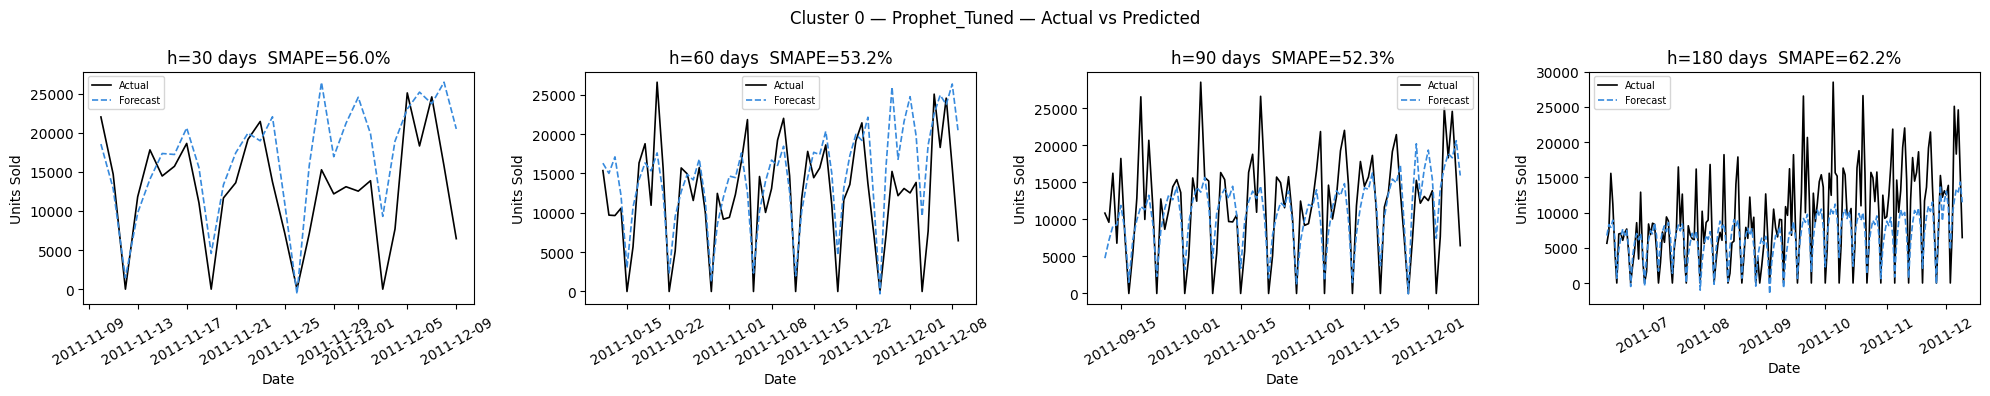

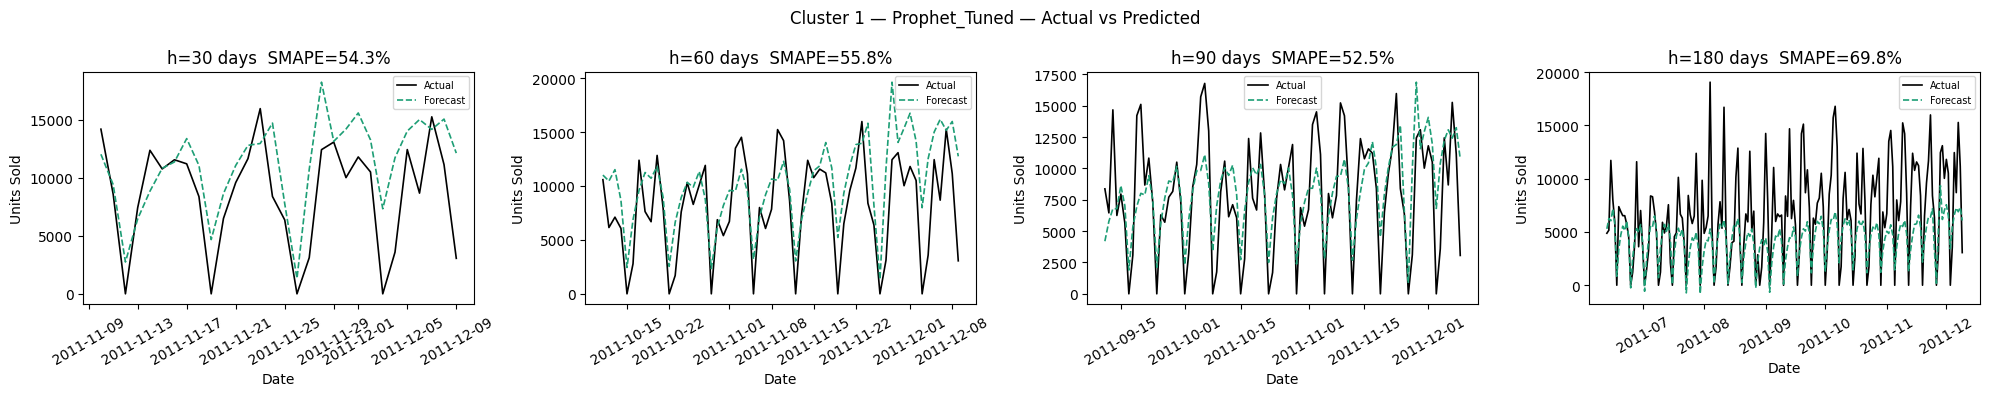

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.8 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 12.8 K                                                                                       
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


...

Trainable params: 3.2 M                                                                                            
Non-trainable params: 129 K                                                                                        
Total params: 3.3 M                                                                                                
Total estimated model params size (MB): 13                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

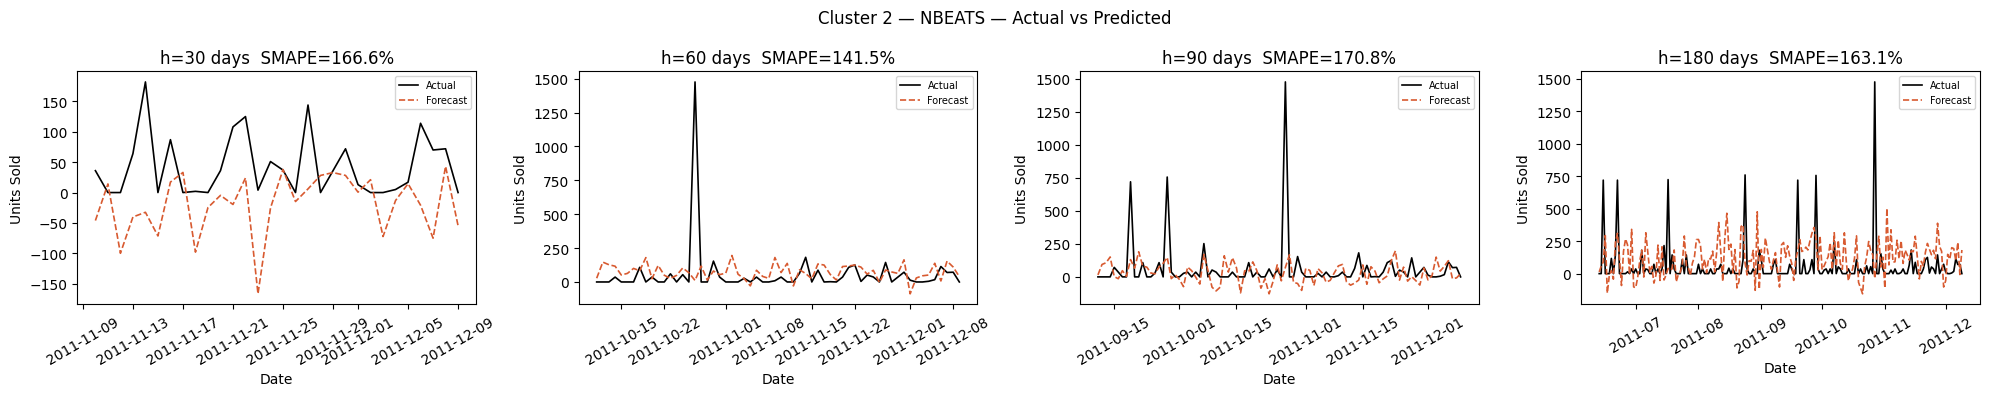

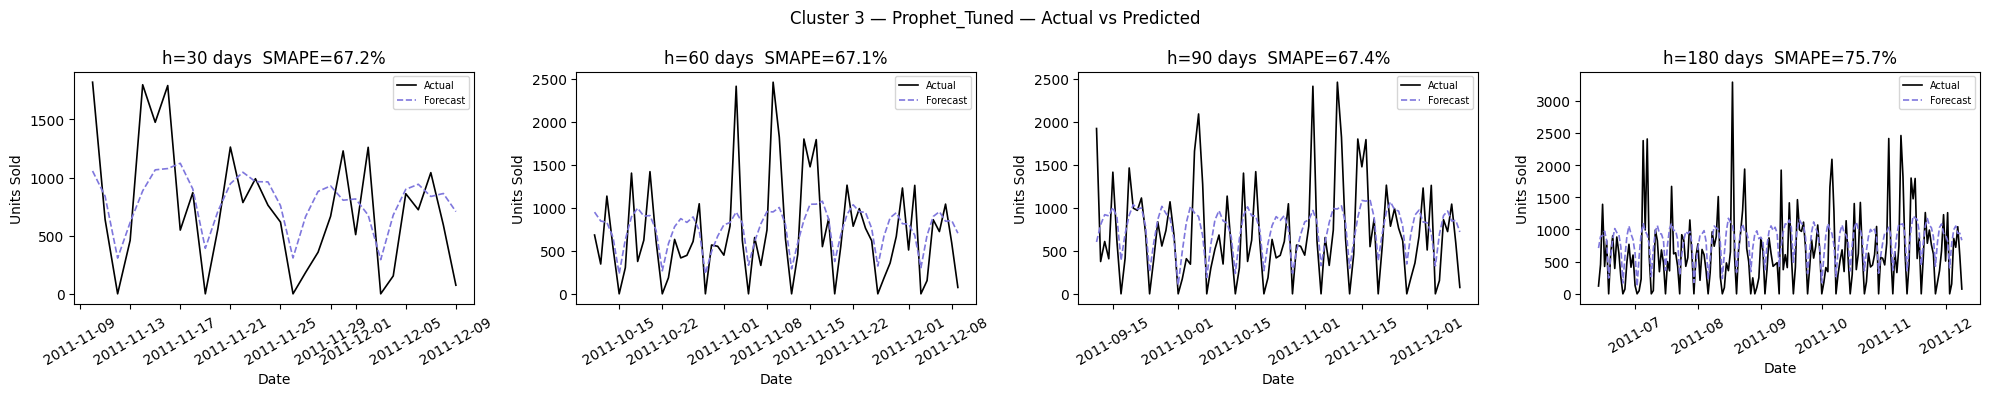

In [135]:
for cluster_id in [0, 1, 2, 3]:
    model_name = best_models[cluster_id]
    df_c       = cluster_dfs[cluster_id].copy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)
    fig.suptitle(f'Cluster {cluster_id} — {model_name} — Actual vs Predicted')

    for j, h in enumerate([30, 60, 90, 180]):
        cutoff = df_c['ds'].max() - pd.Timedelta(days=h)
        train  = df_c[df_c['ds'] <= cutoff][['ds', 'y']].copy()
        test   = df_c[df_c['ds'] >  cutoff][['ds', 'y']].copy()

        if len(test) < h:
            axes[j].set_title(f'h={h} days — insufficient data')
            continue

        if model_name == 'Prophet_Tuned':
            cfg = prophet_configs[cluster_id]
            m   = Prophet(
                seasonality_mode        = cfg['seasonality_mode'],
                yearly_seasonality      = True,
                weekly_seasonality      = True,
                daily_seasonality       = False,
                changepoint_prior_scale = cfg['changepoint_prior_scale'],
                seasonality_prior_scale = cfg['seasonality_prior_scale'],
                holidays_prior_scale    = cfg['holidays_prior_scale'],
                n_changepoints          = cfg['n_changepoints'],
                holidays                = shopping_holidays
            )
            m.add_country_holidays(country_name='UK')
            m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
            m.fit(train)
            future   = m.make_future_dataframe(periods=h)
            forecast = m.predict(future)
            pred_ds  = forecast[forecast['ds'].isin(test['ds'])].sort_values('ds')['ds'].values
            pred_y   = forecast[forecast['ds'].isin(test['ds'])].sort_values('ds')['yhat'].values

        elif model_name == 'NBEATS':
            train_nf              = train.copy()
            train_nf['unique_id'] = f'Cluster_{cluster_id}'
            test_nf               = test.copy()
            test_nf['unique_id']  = f'Cluster_{cluster_id}'

            model = NBEATS(
                h                         = h,
                input_size                = 180,
                n_harmonics               = 2,
                n_polynomials             = 2,
                mlp_units                 = [[512, 512], [512, 512], [512, 512]],
                n_blocks                  = [1, 1, 1],
                max_steps                 = 1000,
                learning_rate             = 1e-4,
                loss                      = MAE(),
                batch_size                = 32,
                early_stop_patience_steps = -1,
                random_seed               = 42
            )
            nf      = NeuralForecast(models=[model], freq='D')
            nf.fit(df=train_nf, val_size=h)
            preds   = nf.predict().reset_index().sort_values('ds')
            pred_ds = preds['ds'].values
            pred_y  = preds['NBEATS'].values

        actual_sorted = test.sort_values('ds')
        n             = min(len(actual_sorted), len(pred_y))
        smape         = np.mean(2 * np.abs(pred_y[:n] - actual_sorted['y'].values[:n]) /
                                (np.abs(actual_sorted['y'].values[:n]) + np.abs(pred_y[:n]) + 1e-8)) * 100

        axes[j].plot(actual_sorted['ds'].values, actual_sorted['y'].values,
                     color='black', linewidth=1.2, label='Actual')
        axes[j].plot(pred_ds[:n], pred_y[:n],
                     color=colors[cluster_id], linewidth=1.2,
                     linestyle='--', label='Forecast')
        axes[j].set_title(f'h={h} days  SMAPE={smape:.1f}%')
        axes[j].set_xlabel('Date')
        axes[j].set_ylabel('Units Sold')
        axes[j].tick_params(axis='x', rotation=30)
        axes[j].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

## 14. Rolling Window Evaluation & Boxplot:

**Objective:**
- Generate multiple SMAPE values per time period to enable a meaningful boxplot with a real distribution.
- A single SMAPE value per period cannot show variability — rolling windows solve this by creating multiple test periods within each seasonal window.

**Rolling Window Methodology:**
- For each time window (Late 2010, Early 2011, Mid 2011, Late 2011) a 30-day sub-window is slid forward in 14-day steps.
- Example sub-windows generated within Late 2010 (September to November 2010):
  - Sub-window 1 — September 1 to September 30.
  - Sub-window 2 — September 15 to October 15.
  - Sub-window 3 — October 1 to October 31.
  - Sub-window 4 — October 15 to November 14.
- Each sub-window generates one SMAPE value — approximately 4 to 5 values per seasonal period.
- All data before each sub-window start date is used as training data.
- The model is retrained from scratch for each sub-window to simulate a true walk-forward evaluation.

**Why Rolling Windows Enable a Real Boxplot:**
- A standard boxplot requires at least 5 values per category to show quartiles, median, whiskers and outliers.
- Rolling windows provide 4 to 5 SMAPE values per seasonal period making the boxplot statistically meaningful.
- The spread of each box shows how consistently the model performs within that time period.
- A tall box indicates high variability — some sub-windows forecasted well and others poorly.
- A short box indicates stable and consistent performance across the period.

**Boxplot Interpretation:**
- Each box represents the distribution of SMAPE values across rolling sub-windows within a seasonal period.
- The median line shows the typical forecast accuracy for that period.
- The whiskers extend to the minimum and maximum SMAPE values excluding outliers.
- Outlier points beyond the whiskers represent sub-windows where the model performed unusually well or poorly.
- A rising median from left to right indicates the model struggles more as the series approaches the peak and decline period of mid to late 2011.
- Comparing medians across clusters reveals which cluster is inherently more predictable regardless of the time period.
- Cluster 2 is expected to show the highest and most variable SMAPE due to its 66% zero-sales days and near-zero autocorrelation structure.

In [142]:
# Define time windows to evaluate across
time_windows = [
    ('2010-09-01', '2010-11-30', 'Late 2010'),
    ('2011-01-01', '2011-03-31', 'Early 2011'),
    ('2011-04-01', '2011-06-30', 'Mid 2011'),
    ('2011-07-01', '2011-09-30', 'Late 2011'),
]

In [140]:
# Generate multiple SMAPE values per window using rolling 30-day sub-windows
rolling_results = []

for cluster_id in [0, 1, 2, 3]:
    model_name = best_models[cluster_id]
    df_c       = cluster_dfs[cluster_id][['ds', 'y']].copy()

    print(f"\nCluster {cluster_id} — {model_name}")

    for start, end, label in time_windows:
        window_start = pd.to_datetime(start)
        window_end   = pd.to_datetime(end)

        sub_start = window_start
        while sub_start + pd.Timedelta(days=30) <= window_end:
            sub_end = sub_start + pd.Timedelta(days=30)

            train = df_c[df_c['ds'] < sub_start][['ds', 'y']].copy()
            test  = df_c[(df_c['ds'] >= sub_start) & (df_c['ds'] < sub_end)][['ds', 'y']].copy()
            h     = len(test)

            if len(train) < 180 or h == 0:
                sub_start += pd.Timedelta(days=14)
                continue

            try:
                if model_name == 'Prophet_Tuned':
                    cfg = prophet_configs[cluster_id]
                    m   = Prophet(
                        seasonality_mode        = cfg['seasonality_mode'],
                        yearly_seasonality      = True,
                        weekly_seasonality      = True,
                        daily_seasonality       = False,
                        changepoint_prior_scale = cfg['changepoint_prior_scale'],
                        seasonality_prior_scale = cfg['seasonality_prior_scale'],
                        holidays_prior_scale    = cfg['holidays_prior_scale'],
                        n_changepoints          = cfg['n_changepoints'],
                        holidays                = shopping_holidays
                    )
                    m.add_country_holidays(country_name='UK')
                    m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
                    m.fit(train)
                    future   = m.make_future_dataframe(periods=h)
                    forecast = m.predict(future)
                    pred_y   = forecast[forecast['ds'].isin(test['ds'])].sort_values('ds')['yhat'].values

                elif model_name == 'NBEATS':
                    train_nf              = train.copy()
                    train_nf['unique_id'] = f'Cluster_{cluster_id}'
                    model = NBEATS(
                        h=h, input_size=min(180, len(train_nf)-h),
                        n_harmonics=2, n_polynomials=2,
                        mlp_units=[[512,512],[512,512],[512,512]],
                        n_blocks=[1,1,1], max_steps=500,
                        learning_rate=1e-4, loss=MAE(),
                        batch_size=32, early_stop_patience_steps=-1,
                        random_seed=42
                    )
                    nf     = NeuralForecast(models=[model], freq='D')
                    nf.fit(df=train_nf, val_size=h)
                    preds  = nf.predict().reset_index().sort_values('ds')
                    pred_y = preds['NBEATS'].values

                actual = test.sort_values('ds')['y'].values
                n      = min(len(actual), len(pred_y))
                smape  = np.mean(2 * np.abs(pred_y[:n] - actual[:n]) /
                                 (np.abs(actual[:n]) + np.abs(pred_y[:n]) + 1e-8)) * 100

                rolling_results.append({
                    'Cluster': f'Cluster_{cluster_id}',
                    'Window' : label,
                    'SMAPE'  : round(smape, 2)
                })
            except Exception as e:
                print(f"  {label} sub-window failed: {e}")

            sub_start += pd.Timedelta(days=14)

rolling_df = pd.DataFrame(rolling_results)
print("\nSMAPE distribution per window:")
print(rolling_df.groupby(['Cluster','Window'])['SMAPE'].describe().round(2).to_string())


Cluster 0 — Prophet_Tuned

Cluster 1 — Prophet_Tuned


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Cluster 2 — NBEATS


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.8 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 12.8 K                                                                                       
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Cluster 3 — Prophet_Tuned

SMAPE distribution per window:
                      count    mean    std     min     25%     50%     75%     max
Cluster   Window                                                                  
Cluster_0 Early 2011    5.0   68.73  10.00   58.80   63.91   65.61   70.28   85.04
          Late 2010     5.0   56.86   6.65   50.20   53.73   55.14   57.45   67.78
          Late 2011     5.0   65.61   5.16   59.39   61.41   66.33   69.28   71.63
          Mid 2011      5.0   75.35  13.61   62.97   63.82   70.16   88.57   91.25
Cluster_1 Early 2011    5.0   87.87  19.67   60.74   80.72   84.58  101.95  111.34
          Late 2010     5.0   53.73   1.77   51.98   52.49   53.53   54.15   56.51
          Late 2011     5.0   67.19   3.41   63.54   63.63   68.16   69.95   70.65
          Mid 2011      5.0   73.76   9.32   62.48   65.18   78.50   79.13   83.53
Cluster_2 Early 2011    5.0  185.37   4.41  180.47  182.21  185.80  186.53  191.86
          Late 2010     5.0 

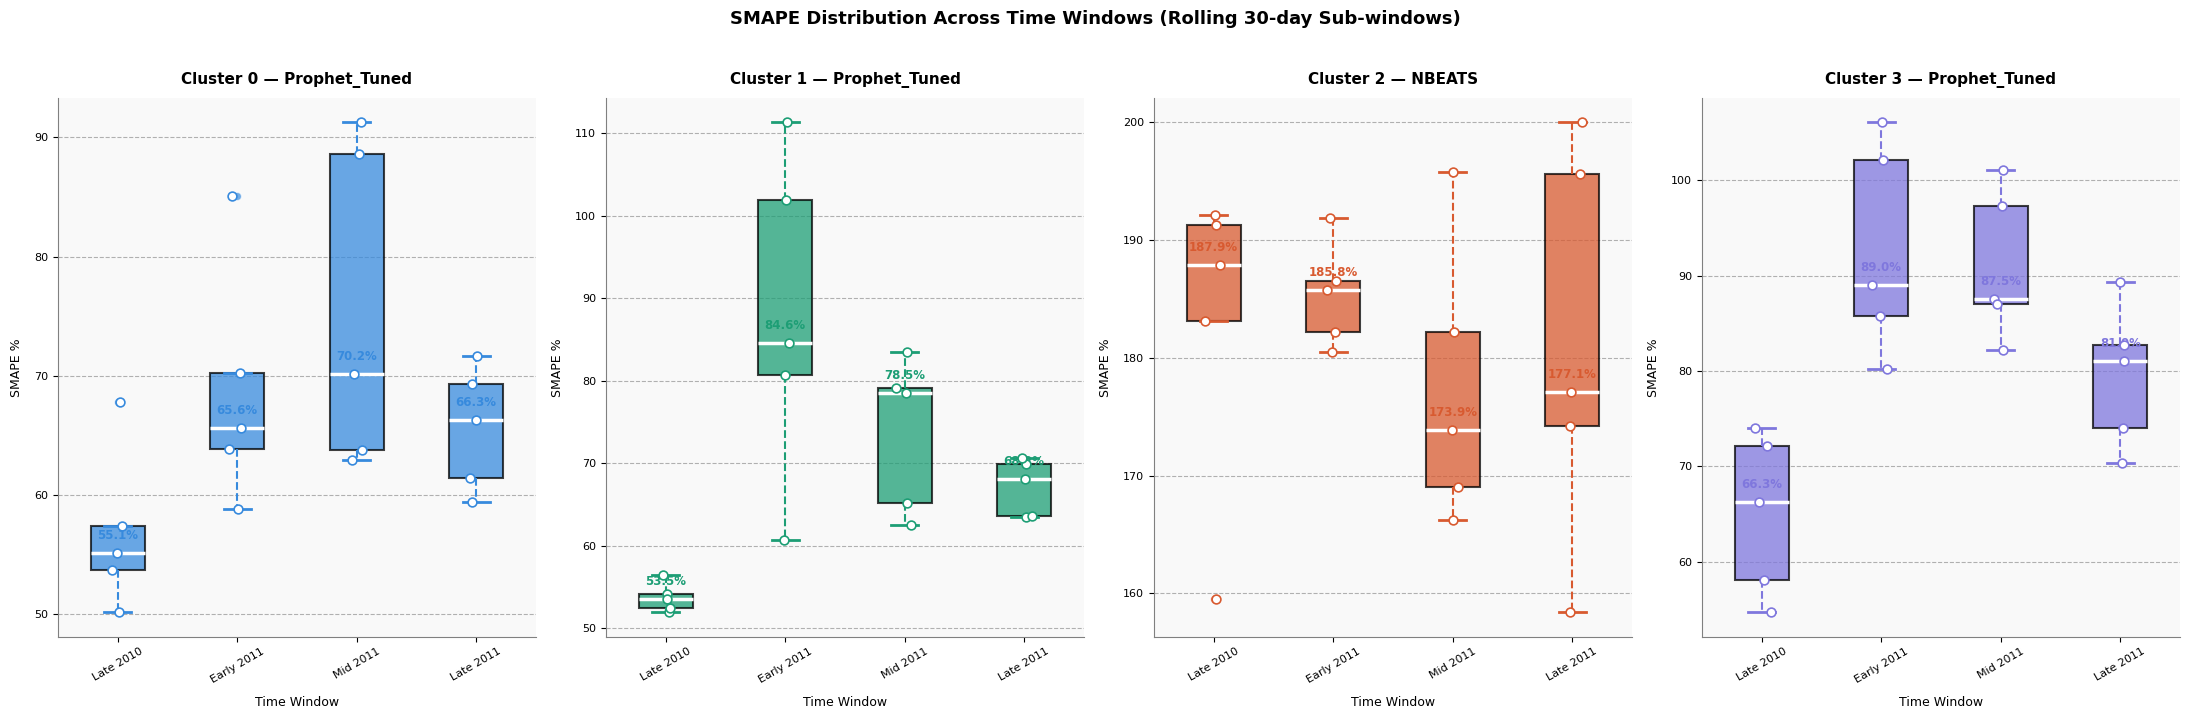

In [143]:
fig, axes = plt.subplots(1, 4, figsize=(22, 7))
colors     = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']
window_labels = ['Late 2010', 'Early 2011', 'Mid 2011', 'Late 2011']

for i, cluster_id in enumerate([0, 1, 2, 3]):
    ax   = axes[i]
    data = rolling_df[rolling_df['Cluster'] == f'Cluster_{cluster_id}']

    smape_values = [data[data['Window'] == w]['SMAPE'].values for w in window_labels]
    valid        = [(v, l) for v, l in zip(smape_values, window_labels) if len(v) > 0]

    if not valid:
        continue

    smape_values, valid_labels = zip(*valid)

    bp = ax.boxplot(smape_values, labels=valid_labels, patch_artist=True,
                    medianprops    = dict(color='white', linewidth=2.5),
                    whiskerprops   = dict(color=colors[i], linewidth=1.5, linestyle='--'),
                    capprops       = dict(color=colors[i], linewidth=2),
                    boxprops       = dict(linewidth=1.5),
                    flierprops     = dict(marker='o', markerfacecolor=colors[i],
                                         markeredgecolor='white', markersize=6, alpha=0.7))

    for patch in bp['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.75)

    # Overlay individual data points
    for j, vals in enumerate(smape_values):
        x_jitter = np.random.normal(j+1, 0.04, size=len(vals))
        ax.scatter(x_jitter, vals, color='white', edgecolors=colors[i],
                   zorder=5, s=40, linewidths=1.2)

        # Annotate median
        median = np.median(vals)
        ax.annotate(f'{median:.1f}%',
                    xy=(j+1, median),
                    textcoords='offset points',
                    xytext=(0, 10),
                    ha='center', fontsize=8.5,
                    fontweight='bold',
                    color=colors[i])

    # Grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='grey', linewidth=0.8)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

    # Spine styling
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('grey')
        ax.spines[spine].set_linewidth(0.8)

    # Background
    ax.set_facecolor('#f9f9f9')

    ax.set_title(f'Cluster {cluster_id} — {best_models[cluster_id]}',
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Time Window', fontsize=9, labelpad=8)
    ax.set_ylabel('SMAPE %', fontsize=9, labelpad=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

fig.patch.set_facecolor('white')
plt.suptitle('SMAPE Distribution Across Time Windows (Rolling 30-day Sub-windows)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()